# Phase 13 — Transformer-Based Gait Encoder: Privacy Profile vs CNN

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Research Question

All previous phases used the **GaitCNN** (4-layer 1-D ConvNet) as the backbone.
This phase asks a fundamentally different question:

> *Does the choice of architecture change the privacy profile of the model?*
> *Specifically: is a Transformer-based gait encoder more or less vulnerable to*
> *membership inference and identity inference than the CNN baseline,*
> *and does CDML protect both architectures equally?*

### Why Transformers have a different privacy profile

The CNN processes the 128-sample IMU window with a **local, hierarchical receptive
field** — each convolution kernel sees a small neighbourhood, and identity features
emerge from stacking local patterns. The embedding vector `h` is an implicit
aggregate of local periodicities (stride, cadence, heel-strike signature).

A Transformer encoder treats the same window as a **sequence of 128 timesteps**,
each with 6 channel features. The self-attention mechanism computes **explicit
pairwise dependencies** between every pair of timesteps at every layer. This has
two competing effects on privacy:

- **More identity-discriminative** → higher IIA AUC: attention can latch onto
  cross-timestep phase relationships that uniquely identify a person's gait rhythm
  (e.g. the ratio of swing-to-stance phase duration), which local convolutions miss.
- **Better generalised** → lower MIA AUC: multi-head self-attention provides
  distributed, overlapping representations that act as implicit regularisation —
  no single weight pathway exclusively memorises a training sample.

**Nobody has measured this trade-off for gait IMU data.** This phase provides
the first systematic comparison.

### Architecture

```
Input: (B, 6, 128)              6-channel × 128-timestep window
  ↓  transpose to (B, 128, 6)
Input projection: Linear(6 → d_model)   project each timestep to d_model dims
  ↓  + learnable positional encoding (128 × d_model)
  ↓  prepend [CLS] token → (B, 129, d_model)
N_LAYERS × TransformerEncoderLayer(d_model, n_heads, dim_ffn, dropout)
  ↓  extract [CLS] output → (B, d_model)
  ↓  LayerNorm
Linear(d_model → embed_dim=128)          matches CNN embedding dimension
  ↓
[CDML: m = s_k ⊙ h]                     identical to CNN-CDML
  ↓
Linear(128 → 118)                        classifier
```

Hyperparameters: `d_model=64`, `n_heads=4`, `N_LAYERS=2`, `dim_ffn=128`,
`dropout=0.1`. This gives ~100k parameters, comparable to GaitCNN (~150k).

### Experiments in this notebook

1. **Architecture comparison** — param count, effective receptive field, attention patterns
2. **CL accuracy** — does the Transformer forget more or less than the CNN?
3. **Embedding geometry** — t-SNE, inter/intra-subject L2 distances, k-NN attribution
4. **Attention analysis** — head specialisation, attention entropy, gait-cycle alignment
5. **MIA comparison** — CE-loss attack AUC/EER: CNN vs Transformer, with/without CDML
6. **IIA comparison** — multi-query aggregation: query count sensitivity
7. **CDML effectiveness** — does CDML protect Transformer as strongly as CNN?
8. **Attention head privacy probe** — do individual heads leak identity information?
9. **Gradient attribution** — which timesteps and channels are most identity-revealing?
10. **Summary** — Pareto scatter + recommendation


## 0. Imports and device

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')
import math

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128    # shared embedding dimension for CNN and Transformer
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50    # 400 = paper-accurate; 50 = fast iteration
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Transformer-specific ──────────────────────────────────────────────────────
# d_model chosen so param count ≈ GaitCNN param count
TRANS_D_MODEL  = 64     # embedding dimension inside the Transformer
TRANS_N_HEADS  = 4      # number of attention heads (head_dim = 64/4 = 16)
TRANS_N_LAYERS = 2      # Transformer encoder depth
TRANS_DIM_FFN  = 128    # feedforward network hidden dimension
TRANS_DROPOUT  = 0.1    # attention + FFN dropout

# ── Analysis settings ────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_QUERY_SWEEP  = [1, 5, 10, 20, 50]   # query count sensitivity
KNN_K            = 5
ATTN_N_SAMPLES   = 50   # windows used for attention visualisation per task

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — identical to all previous phases

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std( axis=(0, 2), keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t  = torch.tensor(X_tr[mask_tr])
        y_t  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions

### 3a — GaitCNN (reference, identical to Phase 3)

In [4]:
# ── GaitCNN backbone ──────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN — Zou et al. 2020 / Milani 2024, Fig. 2."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.arch_name = 'CNN'
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))


# ── CDML layer (architecture-agnostic) ────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(
        np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))


class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence


class WithCDML(nn.Module):
    """
    Generic CDML wrapper that works with ANY backbone that exposes embed().
    Avoids code duplication between GaitCNN_CDML and GaitTransformer_CDML.
    """
    def __init__(self, backbone, seed=CDML_SEED_BASE):
        super().__init__()
        self.backbone  = backbone
        self.cdml      = CDMLLayer(backbone.embed_dim, seed)
        self.seeds     = {}
        self.embed_dim = backbone.embed_dim
        self.arch_name = backbone.arch_name + '+CDML'

    def embed_raw(self, x):       return self.backbone.embed(x)
    def embed_modulated(self, x): return self.cdml(self.backbone.embed(x))
    def embed(self, x):           return self.embed_modulated(x)  # default = modulated

    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))

    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

    def zero_sequence(self):
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)


cnn_ref = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN params: {sum(p.numel() for p in cnn_ref.parameters()):,}')

GaitCNN params: 227,222


### 3b — GaitTransformer

The Transformer treats the 128-timestep window as a **sequence** of timestep tokens.
Each token is the 6-channel sensor reading at one sample, projected to `d_model` dimensions.
A learnable `[CLS]` token is prepended; its output after all encoder layers is the
sequence-level embedding `h`.

**Why [CLS] over pooling?**  
The CLS token learns to aggregate the information it needs via attention — it can
choose to attend to heel-strike events or to specific gait-cycle phases.
Average pooling treats all timesteps equally, losing the temporal structure.
For identity recognition, selective attention should outperform uniform pooling.

In [5]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al. 2017).
    Provides position information without adding learnable parameters.
    For a 128-step gait window at ~50 Hz, the encoding distinguishes
    within-stride phases (toe-off, mid-swing, heel-strike).
    """
    def __init__(self, d_model, max_len=256, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe   = torch.zeros(max_len, d_model)          # (max_len, d_model)
        pos  = torch.arange(max_len).unsqueeze(1)     # (max_len, 1)
        div  = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos.float() * div)
        pe[:, 1::2] = torch.cos(pos.float() * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class GaitTransformer(nn.Module):
    """
    Transformer-based gait identification encoder.

    Input:  (B, C=6, T=128)  — identical format to GaitCNN
    Output: (B, n_classes)

    Internal flow:
      1. Transpose to (B, T, C)
      2. Linear(C → d_model)  — project each timestep
      3. Prepend [CLS] token  → (B, T+1, d_model)
      4. Add sinusoidal positional encoding
      5. N_LAYERS × TransformerEncoderLayer
      6. Extract CLS output → (B, d_model)
      7. LayerNorm + Linear(d_model → embed_dim) → h
      8. Linear(embed_dim → n_classes)

    The embed() method returns h — the CDML layer intercepts here.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 d_model=TRANS_D_MODEL, n_heads=TRANS_N_HEADS,
                 n_layers=TRANS_N_LAYERS, dim_ffn=TRANS_DIM_FFN,
                 dropout=TRANS_DROPOUT):
        super().__init__()
        self.embed_dim = embed_dim
        self.d_model   = d_model
        self.arch_name = 'Transformer'

        # Input projection: each timestep (C-dim) → d_model
        self.input_proj = nn.Linear(n_channels, d_model)

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)

        # Positional encoding (sinusoidal — no extra parameters)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=WINDOW_SIZE + 1,
                                                    dropout=dropout)

        # Transformer encoder stack
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ffn,
            dropout=dropout, batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # Post-encoder normalisation
        self.ln_final = nn.LayerNorm(d_model)

        # Project CLS output → shared embed_dim space
        self.embedding  = nn.Linear(d_model, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

        self._init_weights()

    def _init_weights(self):
        """Xavier init for Linear layers; zero bias."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _encode(self, x):
        """
        Run the full Transformer stack and return CLS output.
        x: (B, C, T) → returns (B, d_model)
        """
        B = x.size(0)
        # (B, C, T) → (B, T, C)
        x = x.transpose(1, 2)              # (B, 128, 6)
        # Project each timestep
        x = self.input_proj(x)             # (B, 128, d_model)
        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)   # (B, 129, d_model)
        # Positional encoding
        x = self.pos_enc(x)                # (B, 129, d_model)
        # Transformer layers
        x = self.transformer(x)            # (B, 129, d_model)
        # Extract CLS token output and normalise
        return self.ln_final(x[:, 0, :])   # (B, d_model)

    def embed(self, x):
        """Return h ∈ R^embed_dim — the CDML interception point."""
        return self.embedding(self._encode(x))

    def forward(self, x):
        return self.classifier(self.embed(x))

    def get_attention_weights(self, x):
        """
        Return per-head attention weight matrices for every Transformer layer.

        WHY A MANUAL FORWARD INSTEAD OF nn.TransformerEncoder DIRECTLY:
        The default nn.TransformerEncoder.forward() calls each layer with
        need_weights=False (for efficiency), which means attention weights are
        never computed. We therefore replay the forward pass manually, calling
        layer.self_attn with need_weights=True and average_attn_weights=False
        to obtain one (T+1, T+1) matrix per head rather than the averaged one.

        Parameters
        ----------
        x : Tensor (B, C, T) — already on the model's device.

        Returns
        -------
        List of length n_layers.
        Each element: Tensor (B, n_heads, T+1, T+1).
        Entry [l][b, h, i, j] = weight assigned by head h of layer l
        in sample b from query token i to key token j.
        Token index 0 is the [CLS] token; indices 1..T are the timesteps.
        """
        self.eval()
        # Collect one tensor per layer; no hooks needed.
        attn_weights_per_layer = []

        with torch.no_grad():
            B = x.size(0)

            # ── Replicate _encode() step-by-step ─────────────────────────────
            # Step 1: (B, C, T) → (B, T, C) — Transformer expects seq-first
            src = x.transpose(1, 2)

            # Step 2: project each 6-channel timestep into d_model dimensions
            src = self.input_proj(src)                    # (B, T, d_model)

            # Step 3: prepend the learnable [CLS] token
            cls = self.cls_token.expand(B, -1, -1)        # (B, 1, d_model)
            src = torch.cat([cls, src], dim=1)            # (B, T+1, d_model)

            # Step 4: add sinusoidal positional encoding
            src = self.pos_enc(src)                       # (B, T+1, d_model)

            # ── Manual layer-by-layer forward with attention capture ──────────
            for layer in self.transformer.layers:
                # Pre-LayerNorm (norm_first=True): normalise BEFORE attention.
                # This improves gradient flow vs the original Post-LN design.
                src_normed = layer.norm1(src)

                # Self-attention: Q = K = V = src_normed (encoder, no masking).
                # need_weights=True:      return the attention weight matrix.
                # average_attn_weights=False: return PER-HEAD weights, shape
                #   (B, n_heads, T+1, T+1), instead of the averaged (B, T+1, T+1).
                attn_out, attn_w = layer.self_attn(
                    src_normed, src_normed, src_normed,
                    need_weights=True,
                    average_attn_weights=False,
                )
                # Store this layer's per-head attention matrices
                attn_weights_per_layer.append(attn_w.detach().cpu())

                # Residual connection after attention (with dropout)
                src = src + layer.dropout1(attn_out)

                # Pre-LN before the Feed-Forward Network
                src_normed2 = layer.norm2(src)

                # FFN: Linear → Activation → Dropout → Linear
                ffn_out = layer.linear2(
                    layer.dropout(
                        layer.activation(layer.linear1(src_normed2))
                    )
                )
                # Residual connection after FFN
                src = src + layer.dropout2(ffn_out)

        return attn_weights_per_layer  # list[n_layers] of (B, n_heads, T+1, T+1)


# ── Sanity checks ─────────────────────────────────────────────────────────────
trans_ref = GaitTransformer(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
dummy     = torch.zeros(4, N_CHANNELS, WINDOW_SIZE)
out       = trans_ref(dummy)
print(f'GaitTransformer output: {out.shape}')
print(f'GaitTransformer params: {sum(p.numel() for p in trans_ref.parameters()):,}')
print(f'GaitCNN params:         {sum(p.numel() for p in cnn_ref.parameters()):,}')
print()

# Parameter breakdown
print('── Transformer parameter breakdown ──')
for name, p in trans_ref.named_parameters():
    print(f'  {name:<45} {p.numel():>8,}')
print(f'  {"TOTAL":<45} {sum(p.numel() for p in trans_ref.parameters()):>8,}')

GaitTransformer output: torch.Size([4, 118])
GaitTransformer params: 91,126
GaitCNN params:         227,222

── Transformer parameter breakdown ──
  cls_token                                           64
  input_proj.weight                                  384
  input_proj.bias                                     64
  transformer.layers.0.self_attn.in_proj_weight   12,288
  transformer.layers.0.self_attn.in_proj_bias        192
  transformer.layers.0.self_attn.out_proj.weight    4,096
  transformer.layers.0.self_attn.out_proj.bias        64
  transformer.layers.0.linear1.weight              8,192
  transformer.layers.0.linear1.bias                  128
  transformer.layers.0.linear2.weight              8,192
  transformer.layers.0.linear2.bias                   64
  transformer.layers.0.norm1.weight                   64
  transformer.layers.0.norm1.bias                     64
  transformer.layers.0.norm2.weight                   64
  transformer.layers.0.norm2.bias                     

## 4. Shared training utilities and evaluation functions

In [6]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t


def compute_roc(member_s, nonmember_s):
    scores = np.concatenate([member_s, nonmember_s])
    labels = np.concatenate([np.ones(len(member_s)), np.zeros(len(nonmember_s))])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = sk_auc(fpr, tpr)
    fnr         = 1 - tpr
    eer         = float(np.mean([fpr[np.nanargmin(np.abs(fpr - fnr))],
                                  fnr[np.nanargmin(np.abs(fpr - fnr))]]))
    return fpr, tpr, roc_auc, eer


@torch.no_grad()
def ce_membership_scores(model, dataset, device, cdml_task=None, batch_size=256):
    """
    CE-loss MIA score: score = -CE(model(x), y).
    Members have low CE loss → high score.
    Numerically stable on MPS (uses log-sum-exp internally).
    """
    model.eval()
    if cdml_task and hasattr(model, 'seeds') and cdml_task in model.seeds:
        model.set_task_sequence(cdml_task, model.seeds[cdml_task])
    criterion = nn.CrossEntropyLoss(reduction='none')
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores    = []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        loss = criterion(model(X_b), y_b).cpu().float().numpy()
        scores.append(-loss)
    return np.concatenate(scores)


@torch.no_grad()
def iia_score(model, X_windows, subj_idx, device, n_queries=IIA_N_QUERIES):
    """
    IIA score for one subject: mean(-CE) over N query windows.
    Higher = model recognises this subject = inferred enrolled.
    """
    model.eval()
    X = X_windows[:n_queries].to(device)
    y = torch.full((len(X),), subj_idx, dtype=torch.long, device=device)
    loss = nn.CrossEntropyLoss(reduction='none')(model(X), y)
    return float((-loss).cpu().float().mean().item())


def run_iia(model, task_data, task_names, device, is_cdml=False,
             cdml_mode='none', n_queries=IIA_N_QUERIES):
    """
    IIA with leave-one-task-out non-member protocol.
    cdml_mode: 'oracle' | 'no_seed' | 'none'
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):
        lo, hi    = TASK_SPLITS[task_name]
        task_subj = [label_to_idx[s] for s in range(lo, hi+1) if s in label_to_idx]
        test_ds   = task_data[task_name]['test']

        if cdml_mode == 'oracle' and is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        elif cdml_mode == 'no_seed' and is_cdml:
            model.zero_sequence()

        member_scores = []
        for subj_idx in task_subj:
            Xm = torch.stack([test_ds[i][0] for i in range(len(test_ds))
                               if test_ds[i][1].item() == subj_idx])
            if len(Xm) == 0: continue
            member_scores.append(iia_score(model, Xm, subj_idx, device, n_queries))

        nonmember_scores = []
        for other_task in [t for t in task_names if t != task_name]:
            # Note: ot_idx not needed; we query using the PROBE task's
            # sequence so results are comparable across member/non-member.
            if cdml_mode == 'oracle' and is_cdml:
                model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
            elif cdml_mode == 'no_seed' and is_cdml:
                model.zero_sequence()
            ot_lo, ot_hi = TASK_SPLITS[other_task]
            ot_ds = task_data[other_task]['test']
            for subj_idx in [label_to_idx[s] for s in range(ot_lo, ot_hi+1)
                              if s in label_to_idx]:
                Xnm = torch.stack([ot_ds[i][0] for i in range(len(ot_ds))
                                   if ot_ds[i][1].item() == subj_idx])
                if len(Xnm) == 0: continue
                nonmember_scores.append(
                    iia_score(model, Xnm, subj_idx, device, n_queries))

        m_arr  = np.array(member_scores)
        nm_arr = np.array(nonmember_scores[:len(m_arr)])
        _, _, roc_auc, eer = compute_roc(m_arr, nm_arr)
        results[task_name] = {'auc': roc_auc, 'eer': eer,
                               'm_scores': m_arr, 'nm_scores': nm_arr}
    return results


def train_model(model_factory, task_data, task_names, device,
                 epochs, lr_init, lr_decay, batch_size,
                 is_cdml=False, label='', verbose_every=25):
    """
    Generic sequential CL training loop.
    model_factory: callable → returns a fresh model instance.
    Returns (trained_model, acc_matrix[n_tasks x n_tasks]).
    """
    torch.manual_seed(RANDOM_SEED)
    model      = model_factory().to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        if is_cdml:
            model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}'
              + (f'  (s={seed_k})' if is_cdml else ''))

        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            if is_cdml:
                model.set_task_sequence(task_name, seed_k)
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                if is_cdml:
                    model.set_task_sequence(task_name, seed_k)
                vl  = DataLoader(task_data[task_name]['val'],
                                 batch_size=batch_size)
                val = evaluate(model, vl, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val:.3f}')

        for ei, et in enumerate(task_names[:step_idx + 1]):
            if is_cdml:
                model.set_task_sequence(et, model.seeds[et])
            tl  = DataLoader(task_data[et]['test'], batch_size=batch_size)
            acc_matrix[step_idx, ei] = evaluate(model, tl, device)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                          for j in range(step_idx+1)])
        print(f'  → {row}')

    return model, acc_matrix


print('Utilities defined.')

Utilities defined.


## 5. Train all four model variants

- **CNN** — GaitCNN, standard CL (no CDML)
- **CNN+CDML** — GaitCNN with CDML (Phase 3 baseline)
- **Transformer** — GaitTransformer, standard CL
- **Transformer+CDML** — GaitTransformer with CDML (novel)

In [7]:
print('='*60)
print('Training CNN (standard)...')
print('='*60)
model_cnn, acc_cnn = train_model(
    lambda: GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM),
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    is_cdml=False, label='CNN'
)

print('\n' + '='*60)
print('Training CNN+CDML...')
print('='*60)
model_cnn_cdml, acc_cnn_cdml = train_model(
    lambda: WithCDML(GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)),
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    is_cdml=True, label='CNN+CDML'
)

print('\n' + '='*60)
print('Training Transformer (standard)...')
print('='*60)
model_trans, acc_trans = train_model(
    lambda: GaitTransformer(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM),
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    is_cdml=False, label='Transformer'
)

print('\n' + '='*60)
print('Training Transformer+CDML...')
print('='*60)
model_trans_cdml, acc_trans_cdml = train_model(
    lambda: WithCDML(GaitTransformer(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)),
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    is_cdml=True, label='Transformer+CDML'
)

ALL_MODELS = [
    ('CNN',              model_cnn,        acc_cnn,        False, '#E74C3C'),
    ('CNN+CDML',         model_cnn_cdml,   acc_cnn_cdml,   True,  '#3498DB'),
    ('Transformer',      model_trans,      acc_trans,      False, '#E67E22'),
    ('Transformer+CDML', model_trans_cdml, acc_trans_cdml, True,  '#27AE60'),
]

print('\n── Final accuracy (after Task 4) ──')
print(f'  {"Model":<22}  T1      T2      T3      T4      Avg')
print('  ' + '─'*62)
for label, _, mat, *_ in ALL_MODELS:
    vals = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg  = np.nanmean(mat[-1,:]) * 100
    print(f'  {label:<22}  ' + '  '.join(f'{v:5.1f}%' for v in vals) + f'  {avg:5.1f}%')

Training CNN (standard)...
[CNN] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[CNN] Step 2: Task 2
  Epoch   1/50  val=0.934
  Epoch  25/50  val=0.979
  Epoch  50/50  val=0.982
  → T1:0.3%  T2:93.6%
[CNN] Step 3: Task 3
  Epoch   1/50  val=0.936
  Epoch  25/50  val=0.975
  Epoch  50/50  val=0.975
  → T1:0.0%  T2:0.0%  T3:92.8%
[CNN] Step 4: Task 4
  Epoch   1/50  val=0.961
  Epoch  25/50  val=0.982
  Epoch  50/50  val=0.980
  → T1:0.0%  T2:0.0%  T3:0.0%  T4:98.0%

Training CNN+CDML...
[CNN+CDML] Step 1: Task 1  (s=1000)
  Epoch   1/50  val=0.941
  Epoch  25/50  val=0.989
  Epoch  50/50  val=0.991
  → T1:89.7%
[CNN+CDML] Step 2: Task 2  (s=1001)
  Epoch   1/50  val=0.955
  Epoch  25/50  val=0.987
  Epoch  50/50  val=0.987
  → T1:79.6%  T2:95.4%
[CNN+CDML] Step 3: Task 3  (s=1002)
  Epoch   1/50  val=0.944
  Epoch  25/50  val=0.984
  Epoch  50/50  val=0.984
  → T1:62.6%  T2:73.9%  T3:92.3%
[CNN+CDML] Step 4: Task 4  (s=1003)
  

## 6. Accuracy and Forgetting Analysis

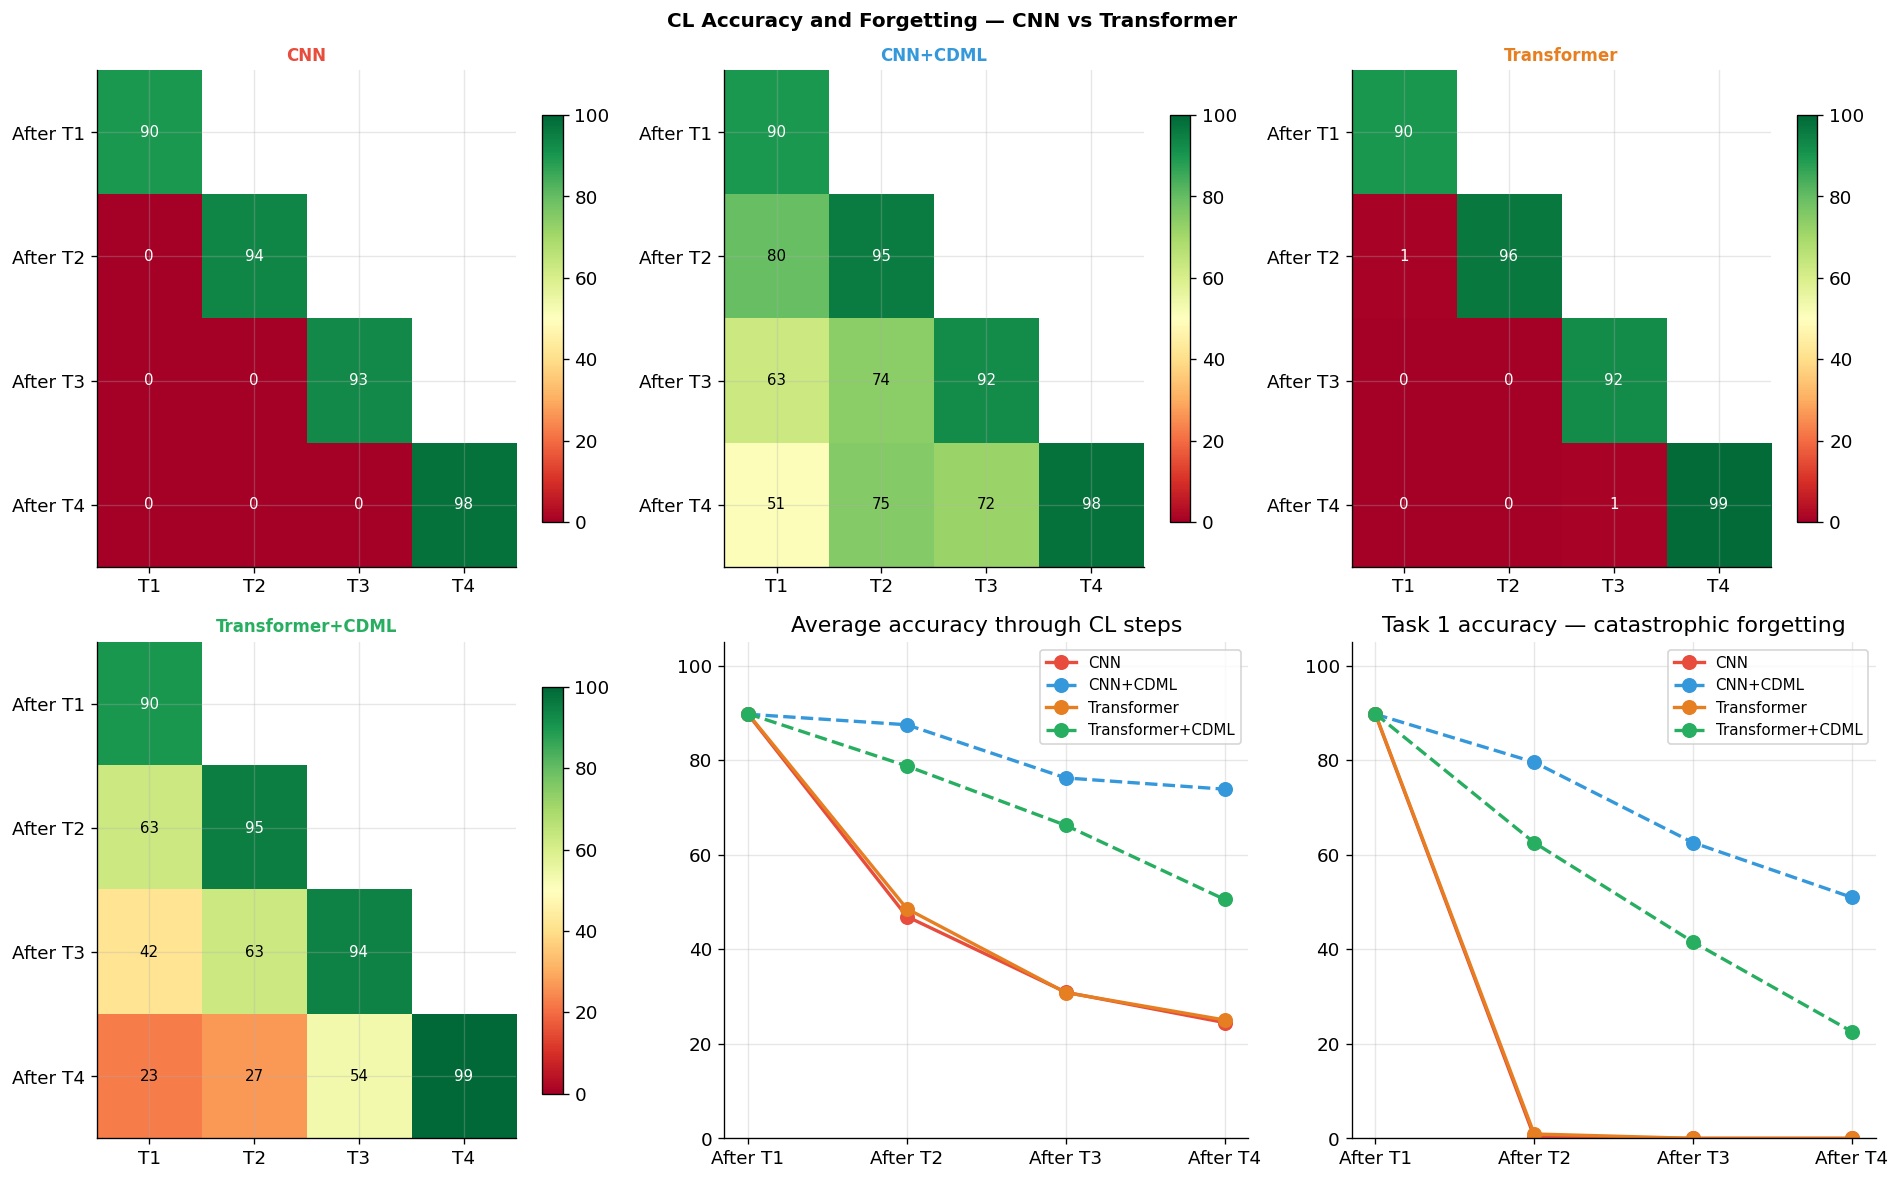


── Forgetting summary ──
  Model                   T1_init  T1_final  Drop(pp)  Avg_final
  ──────────────────────────────────────────────────────────────
  CNN                       89.7%      0.0%     89.7      24.5%  BWT=-92.0pp
  CNN+CDML                  89.7%     51.0%     38.8      73.9%  BWT=-26.6pp
  Transformer               89.8%      0.0%     89.8      25.0%  BWT=-92.5pp
  Transformer+CDML          89.8%     22.6%     67.3      50.6%  BWT=-58.7pp


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Accuracy matrices: 4 subplots arranged as [0,0] [0,1] [0,2] [1,0] ─────
# Row = step (after which task training completed)
# Col = task being evaluated  →  diagonal = current task, off-diagonal = forgetting
axes_flat = [axes[0,0], axes[0,1], axes[0,2], axes[1,0]]
for ax, (label, _, mat, _, color) in zip(axes_flat, ALL_MODELS):
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.82)
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(label, fontsize=10, fontweight='bold', color=color)
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=9, color='black' if 20 < v < 85 else 'white')

# ── Bottom centre: average accuracy curves ────────────────────────────────────
ax_avg = axes[1, 1]
for label, _, mat, _, color in ALL_MODELS:
    avg = [np.nanmean(mat[s, :s+1]) * 100 for s in range(n_tasks)]
    ls  = '--' if 'CDML' in label else '-'
    ax_avg.plot(range(1, n_tasks+1), avg, marker='o', color=color,
                ls=ls, lw=2, ms=8, label=label)
ax_avg.set_xticks(range(1, n_tasks+1))
ax_avg.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
ax_avg.set_ylim(0, 105)
ax_avg.set_title('Average accuracy through CL steps')
ax_avg.legend(fontsize=9)

# ── Bottom right: forgetting per architecture ─────────────────────────────────
ax_fgt = axes[1, 2]
for label, _, mat, _, color in ALL_MODELS:
    t1 = [mat[s, 0] * 100 for s in range(n_tasks)]
    ls = '--' if 'CDML' in label else '-'
    ax_fgt.plot(range(1, n_tasks+1), t1, marker='o', color=color,
                ls=ls, lw=2, ms=8, label=label)
ax_fgt.set_xticks(range(1, n_tasks+1))
ax_fgt.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
ax_fgt.set_ylim(0, 105)
ax_fgt.set_title('Task 1 accuracy — catastrophic forgetting')
ax_fgt.legend(fontsize=9)

plt.suptitle('CL Accuracy and Forgetting — CNN vs Transformer', fontsize=12,
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_accuracy.png', bbox_inches='tight')
plt.show()

# ── Numeric forgetting summary ────────────────────────────────────────────────
print('\n── Forgetting summary ──')
print(f'  {"Model":<22}  T1_init  T1_final  Drop(pp)  Avg_final')
print('  ' + '─'*62)
for label, _, mat, *_ in ALL_MODELS:
    t1_init  = mat[0, 0] * 100
    t1_final = mat[-1, 0] * 100
    avg_f    = np.nanmean(mat[-1, :]) * 100
    bwt      = np.nanmean([mat[-1, j] - mat[j, j]
                            for j in range(n_tasks - 1)]) * 100
    print(f'  {label:<22}  {t1_init:>6.1f}%  {t1_final:>7.1f}%  '
          f'{t1_init-t1_final:>7.1f}    {avg_f:>6.1f}%  '
          f'BWT={bwt:+.1f}pp')

## 7. Attention Pattern Analysis

### 7a — Attention weight visualisation
The attention weight matrix shows which pairs of timesteps the model
learns to correlate. For gait, we expect to see:
- Diagonal bands (local temporal proximity)
- Periodic off-diagonal blocks (stride-to-stride correlations, ~50–60 samples at 50 Hz)
- Strong CLS row (what does the CLS token attend to?)

Computing attention weights (Transformer)...
Computing attention weights (Transformer+CDML)...


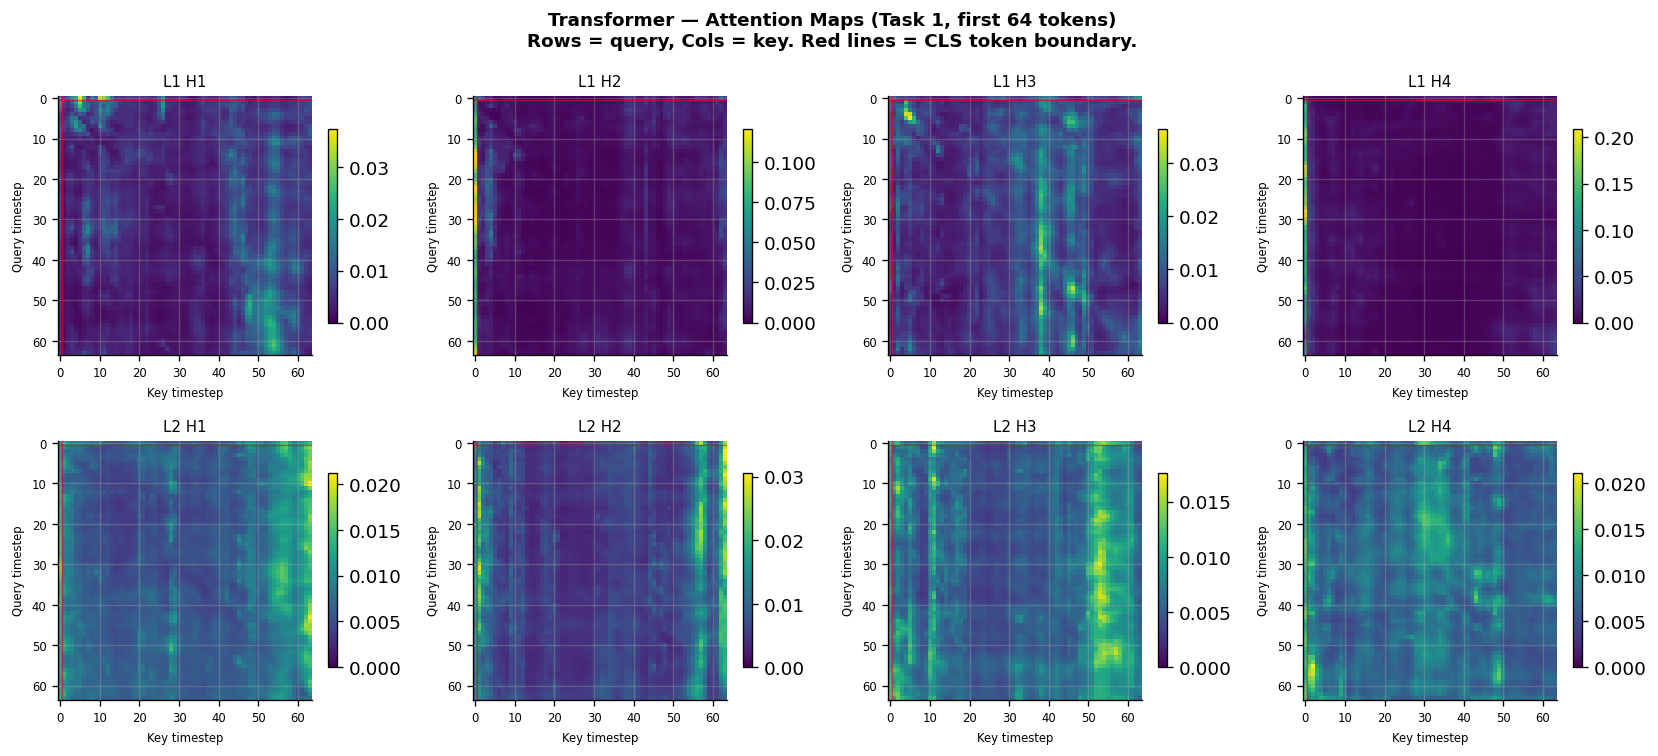

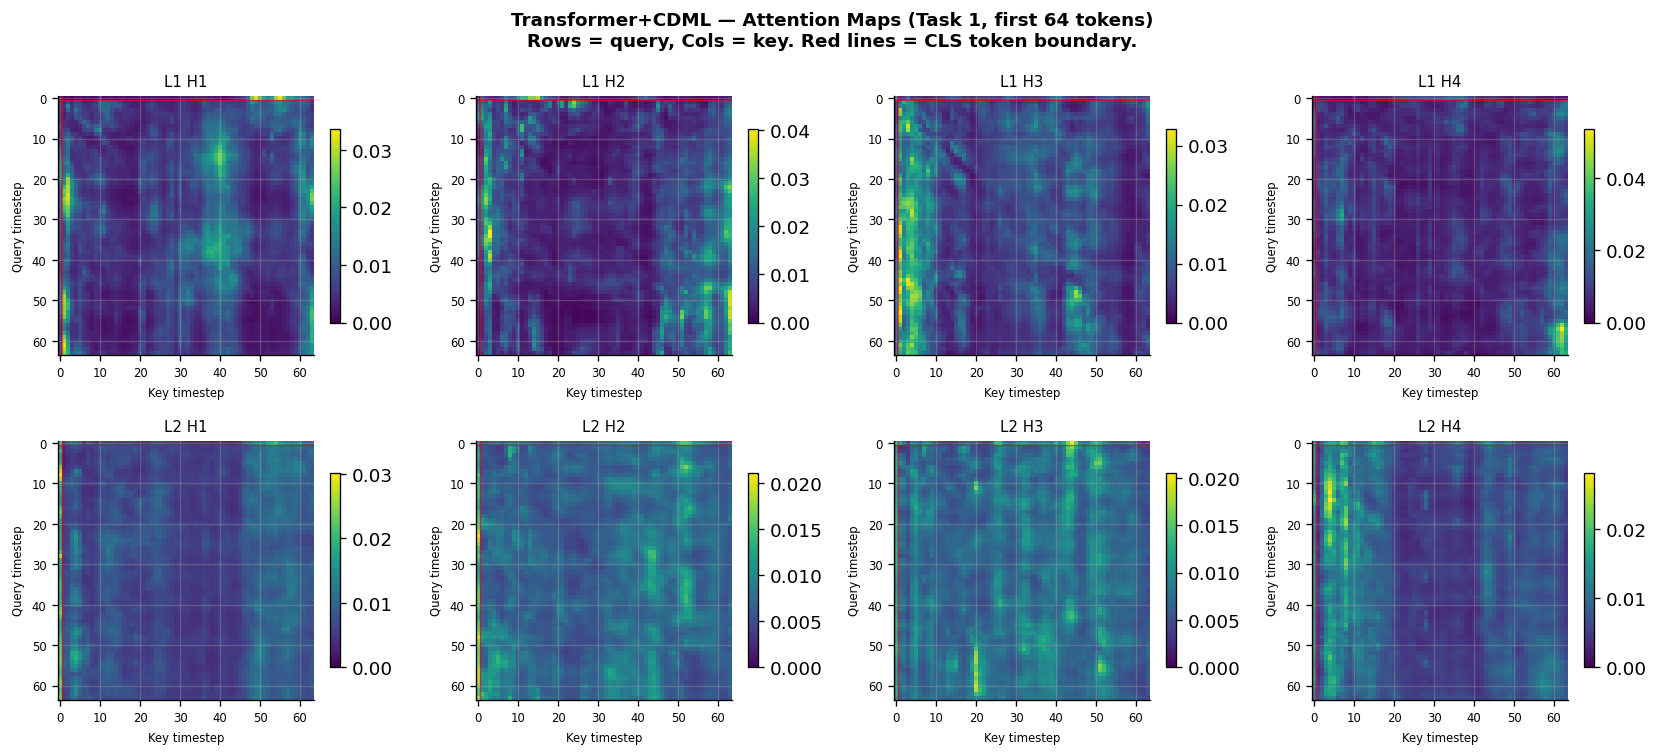

In [9]:
def get_mean_attention(transformer_model, task_data, task_names, device,
                        n_samples=ATTN_N_SAMPLES):
    """
    Compute mean attention maps averaged over n_samples windows per task.
    Returns dict {task: [layer_attn(n_heads, T+1, T+1), ...]}
    """
    backbone = transformer_model.backbone if hasattr(transformer_model, 'backbone') \
               else transformer_model
    result = {}
    for task_name in task_names:
        ds    = task_data[task_name]['test']
        idx   = torch.randperm(len(ds))[:n_samples].tolist()
        X_s   = torch.stack([ds[i][0] for i in idx]).to(device)
        attn_layers = backbone.get_attention_weights(X_s)
        # Average over samples → (n_heads, T+1, T+1) per layer
        result[task_name] = [a.mean(0).numpy() for a in attn_layers]
    return result


print('Computing attention weights (Transformer)...')
attn_std  = get_mean_attention(model_trans,      task_data, task_names, DEVICE)
print('Computing attention weights (Transformer+CDML)...')
attn_cdml = get_mean_attention(model_trans_cdml, task_data, task_names, DEVICE)


# ── Visualise: Layer × Head grid for Task 1 ───────────────────────────────────
def plot_attention_grid(attn_dict, task='Task 1', title='', max_seq=64):
    """
    Plot attention maps for all layers and heads.
    Truncates to max_seq tokens for readability (CLS + first max_seq-1 timesteps).
    """
    layers = attn_dict[task]   # list of (n_heads, T+1, T+1)
    n_layers = len(layers)
    n_heads  = layers[0].shape[0]
    T        = min(max_seq, layers[0].shape[1])

    fig, axes = plt.subplots(n_layers, n_heads,
                              figsize=(3.5 * n_heads, 3.2 * n_layers))
    if n_layers == 1:
        axes = axes[np.newaxis, :]

    for li in range(n_layers):
        a = layers[li][:, :T, :T]   # (n_heads, T, T)
        for hi in range(n_heads):
            ax = axes[li, hi]
            im = ax.imshow(a[hi], cmap='viridis', aspect='auto',
                           vmin=0, vmax=a[hi].max())
            ax.set_title(f'L{li+1} H{hi+1}', fontsize=9)
            ax.set_xlabel('Key timestep', fontsize=7)
            ax.set_ylabel('Query timestep', fontsize=7)
            ax.tick_params(labelsize=7)
            # Mark the CLS position (index 0) with a red line
            ax.axhline(0.5, color='red', lw=0.8, alpha=0.6)
            ax.axvline(0.5, color='red', lw=0.8, alpha=0.6)
            plt.colorbar(im, ax=ax, shrink=0.75)

    plt.suptitle(f'{title} — Attention Maps ({task}, first {T} tokens)\n'
                 'Rows = query, Cols = key. Red lines = CLS token boundary.',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_p13_attn_{title.replace(" ","_").replace("+","")}.png',
                bbox_inches='tight')
    plt.show()


plot_attention_grid(attn_std,  task='Task 1', title='Transformer')
plot_attention_grid(attn_cdml, task='Task 1', title='Transformer+CDML')

### 7b — CLS attention row: what does the model "look at"?

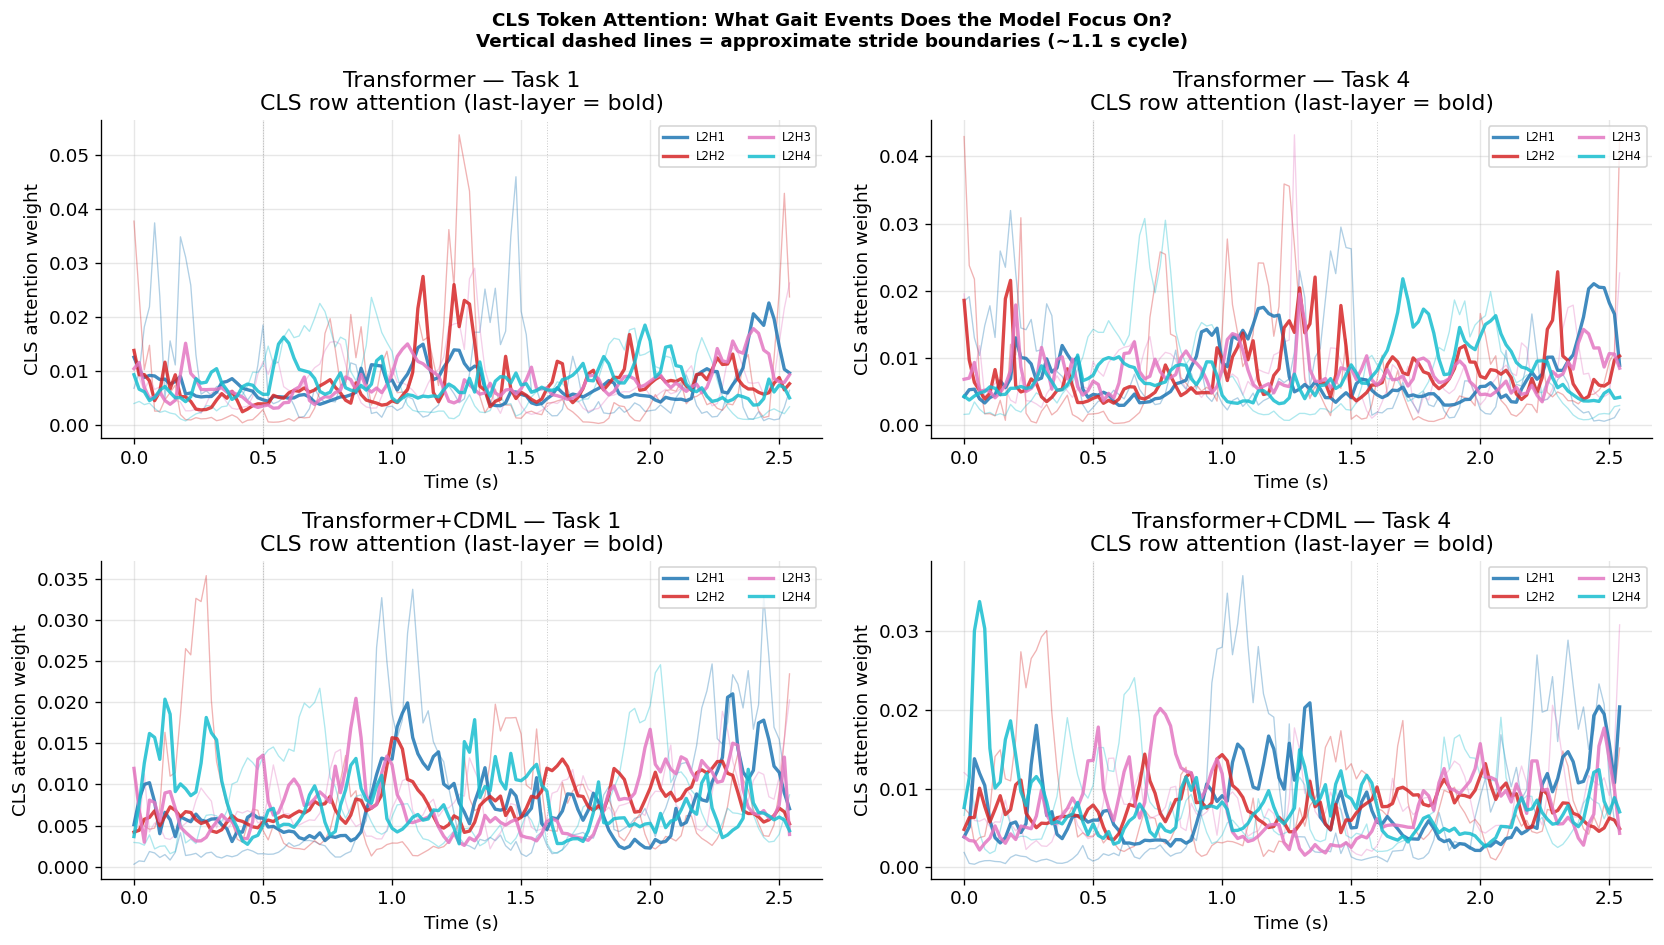

In [10]:
# CLS attention row: how much does the CLS token attend to each timestep?
# A peaked distribution → model relies on a few key gait events.
# A flat distribution  → model integrates information uniformly.

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
t_axis = np.arange(WINDOW_SIZE) / 50.0   # convert samples to seconds at ~50 Hz

for row, (attn_dict, title) in enumerate([
    (attn_std,  'Transformer'),
    (attn_cdml, 'Transformer+CDML')
]):
    for col, task in enumerate(['Task 1', 'Task 4']):
        ax = axes[row, col]
        layers = attn_dict[task]

        for li, layer_attn in enumerate(layers):   # (n_heads, T+1, T+1)
            # CLS row: layer_attn[:, 0, 1:]  → (n_heads, T)
            cls_row = layer_attn[:, 0, 1:]   # exclude CLS-to-CLS
            head_colors = plt.cm.tab10(np.linspace(0, 1, TRANS_N_HEADS))
            for hi in range(TRANS_N_HEADS):
                alpha = 0.85 if li == len(layers) - 1 else 0.35
                lw    = 2.0  if li == len(layers) - 1 else 0.8
                ax.plot(t_axis, cls_row[hi],
                        color=head_colors[hi], alpha=alpha, lw=lw,
                        label=f'L{li+1}H{hi+1}' if li == len(layers)-1 else '')

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('CLS attention weight')
        ax.set_title(f'{title} — {task}\nCLS row attention (last-layer = bold)')
        ax.legend(fontsize=7, ncol=2)

        # Annotate approximate gait cycle period
        # At ~50 Hz, one stride ≈ 50–60 samples = 1.0–1.2 s
        for stride_t in np.arange(0.5, WINDOW_SIZE/50.0, 1.1):
            ax.axvline(stride_t, color='gray', ls=':', lw=0.6, alpha=0.4)

plt.suptitle('CLS Token Attention: What Gait Events Does the Model Focus On?\n'
             'Vertical dashed lines = approximate stride boundaries (~1.1 s cycle)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_cls_attention.png', bbox_inches='tight')
plt.show()

### 7c — Attention entropy: head specialisation vs diffusion

── Attention entropy and head diversity ──
  Model                   Task      entropy per layer [one value per head]  |  head diversity per layer
  (entropy: low=focused/specialised, high=diffuse  |  diversity: high=heads differ from each other)
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Transformer             Task 1    entropy: L1=[4.63 4.45 4.70 4.39] | L2=[4.80 4.77 4.81 4.83]  diversity: L1:0.442 | L2:0.097
  Transformer             Task 2    entropy: L1=[4.67 4.67 4.75 4.60] | L2=[4.78 4.79 4.81 4.82]  diversity: L1:0.296 | L2:0.107
  Transformer             Task 3    entropy: L1=[4.69 4.64 4.73 4.50] | L2=[4.78 4.78 4.79 4.80]  diversity: L1:0.336 | L2:0.125
  Transformer             Task 4    entropy: L1=[4.66 4.62 4.69 4.54] | L2=[4.79 4.79 4.82 4.81]  diversity: L1:0.361 | L2:0.103
  Transformer+CDML        Task 1    entropy: L1=[4.68 4.63 4.70 4.71] | L2=[4.81 4.83 4.83 4.79]  diversity: L1:0.

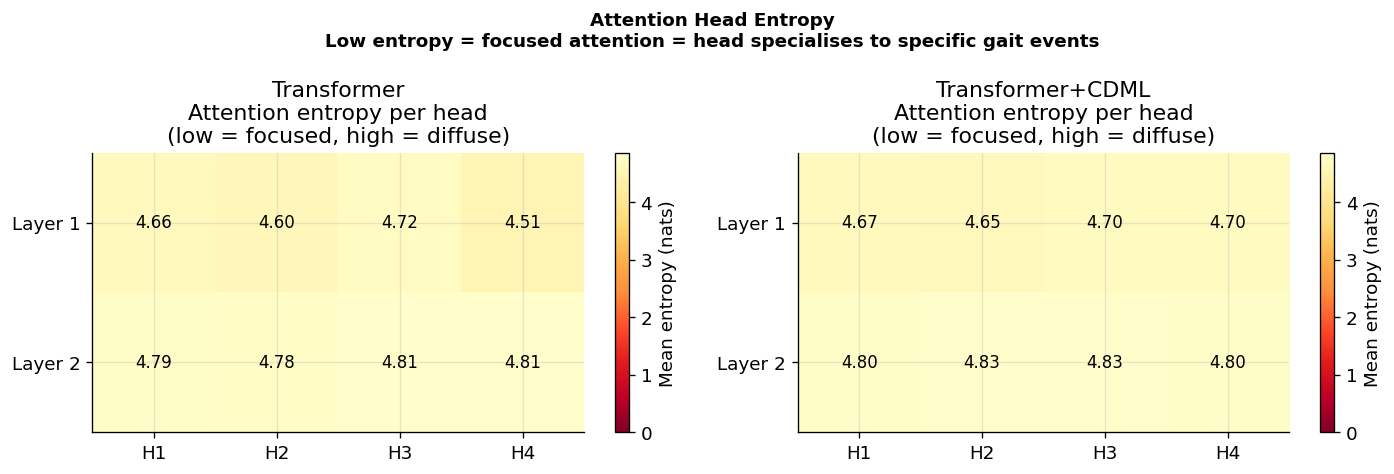

In [11]:
def attention_entropy(attn_matrix):
    """
    Compute Shannon entropy of each row of the attention matrix.
    attn_matrix: (n_heads, T, T)
    Returns mean entropy per head: (n_heads,)
    """
    eps = 1e-12
    # Row-normalise (should already sum to 1, but numerical safety)
    A = attn_matrix / (attn_matrix.sum(-1, keepdims=True) + eps)
    H = -(A * np.log(A + eps)).sum(-1)   # (n_heads, T)
    return H.mean(-1)   # (n_heads,)


def head_diversity(attn_matrix):
    """
    Mean pairwise cosine distance between heads' attention patterns.
    High diversity = heads specialise to different aspects of the sequence.
    attn_matrix: (n_heads, T, T)
    Returns scalar.
    """
    n_heads = attn_matrix.shape[0]
    flat    = attn_matrix.reshape(n_heads, -1)   # (n_heads, T*T)
    flat    = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + 1e-12)
    cos_sim = flat @ flat.T   # (n_heads, n_heads)
    # Mean off-diagonal distance
    mask    = 1 - np.eye(n_heads)
    return float((1 - cos_sim[mask.astype(bool)]).mean())


print('── Attention entropy and head diversity ──')
print(f'  {"Model":<22}  {"Task":<8}  '
      'entropy per layer [one value per head]  |  head diversity per layer\n'
      '  (entropy: low=focused/specialised, high=diffuse  '
      '|  diversity: high=heads differ from each other)')
print('  ' + '─'*120)

for model_label, attn_dict in [
    ('Transformer',      attn_std),
    ('Transformer+CDML', attn_cdml)
]:
    for task in task_names:
        layers = attn_dict[task]
        # Collect entropy and diversity per layer so we can report
        # each layer's values — div was previously only storing the
        # LAST layer because it was reassigned on every iteration.
        per_layer_ent = []
        per_layer_div = []
        for li, layer_attn in enumerate(layers):
            ent = attention_entropy(layer_attn)   # (n_heads,)
            div = head_diversity(layer_attn)      # scalar
            per_layer_ent.append(ent)
            per_layer_div.append(div)
        # Build one readable row per (model, task)
        ent_parts = [
            f"L{li+1}=[" + " ".join(f"{e:.2f}" for e in ent) + "]"
            for li, ent in enumerate(per_layer_ent)
        ]
        div_parts = [
            f"L{li+1}:{d:.3f}" for li, d in enumerate(per_layer_div)
        ]
        row = (f'  {model_label:<22}  {task:<8}  '
               f'entropy: {" | ".join(ent_parts)}  '
               f'diversity: {" | ".join(div_parts)}')
        print(row)


# ── Entropy heatmap ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (model_label, attn_dict) in zip(axes, [
    ('Transformer', attn_std), ('Transformer+CDML', attn_cdml)
]):
    ent_matrix = np.zeros((TRANS_N_LAYERS, TRANS_N_HEADS, n_tasks))
    for t_idx, task in enumerate(task_names):
        for li, layer_attn in enumerate(attn_dict[task]):
            ent_matrix[li, :, t_idx] = attention_entropy(layer_attn)

    # Mean over tasks
    ent_mean = ent_matrix.mean(-1)   # (n_layers, n_heads)
    im = ax.imshow(ent_mean, cmap='YlOrRd_r', aspect='auto',
                   vmin=0, vmax=np.log(WINDOW_SIZE + 1))
    plt.colorbar(im, ax=ax, label='Mean entropy (nats)')
    ax.set_xticks(range(TRANS_N_HEADS))
    ax.set_xticklabels([f'H{i+1}' for i in range(TRANS_N_HEADS)])
    ax.set_yticks(range(TRANS_N_LAYERS))
    ax.set_yticklabels([f'Layer {i+1}' for i in range(TRANS_N_LAYERS)])
    ax.set_title(f'{model_label}\nAttention entropy per head\n'
                 '(low = focused, high = diffuse)')
    for li in range(TRANS_N_LAYERS):
        for hi in range(TRANS_N_HEADS):
            ax.text(hi, li, f'{ent_mean[li,hi]:.2f}', ha='center',
                    va='center', fontsize=10, color='white' if ent_mean[li,hi] < 2 else 'black')

plt.suptitle('Attention Head Entropy\n'
             'Low entropy = focused attention = head specialises to specific gait events',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_attn_entropy.png', bbox_inches='tight')
plt.show()

## 8. Embedding Geometry Analysis

### 8a — t-SNE of embeddings

Extracting embeddings for t-SNE...
Done. Running t-SNE...


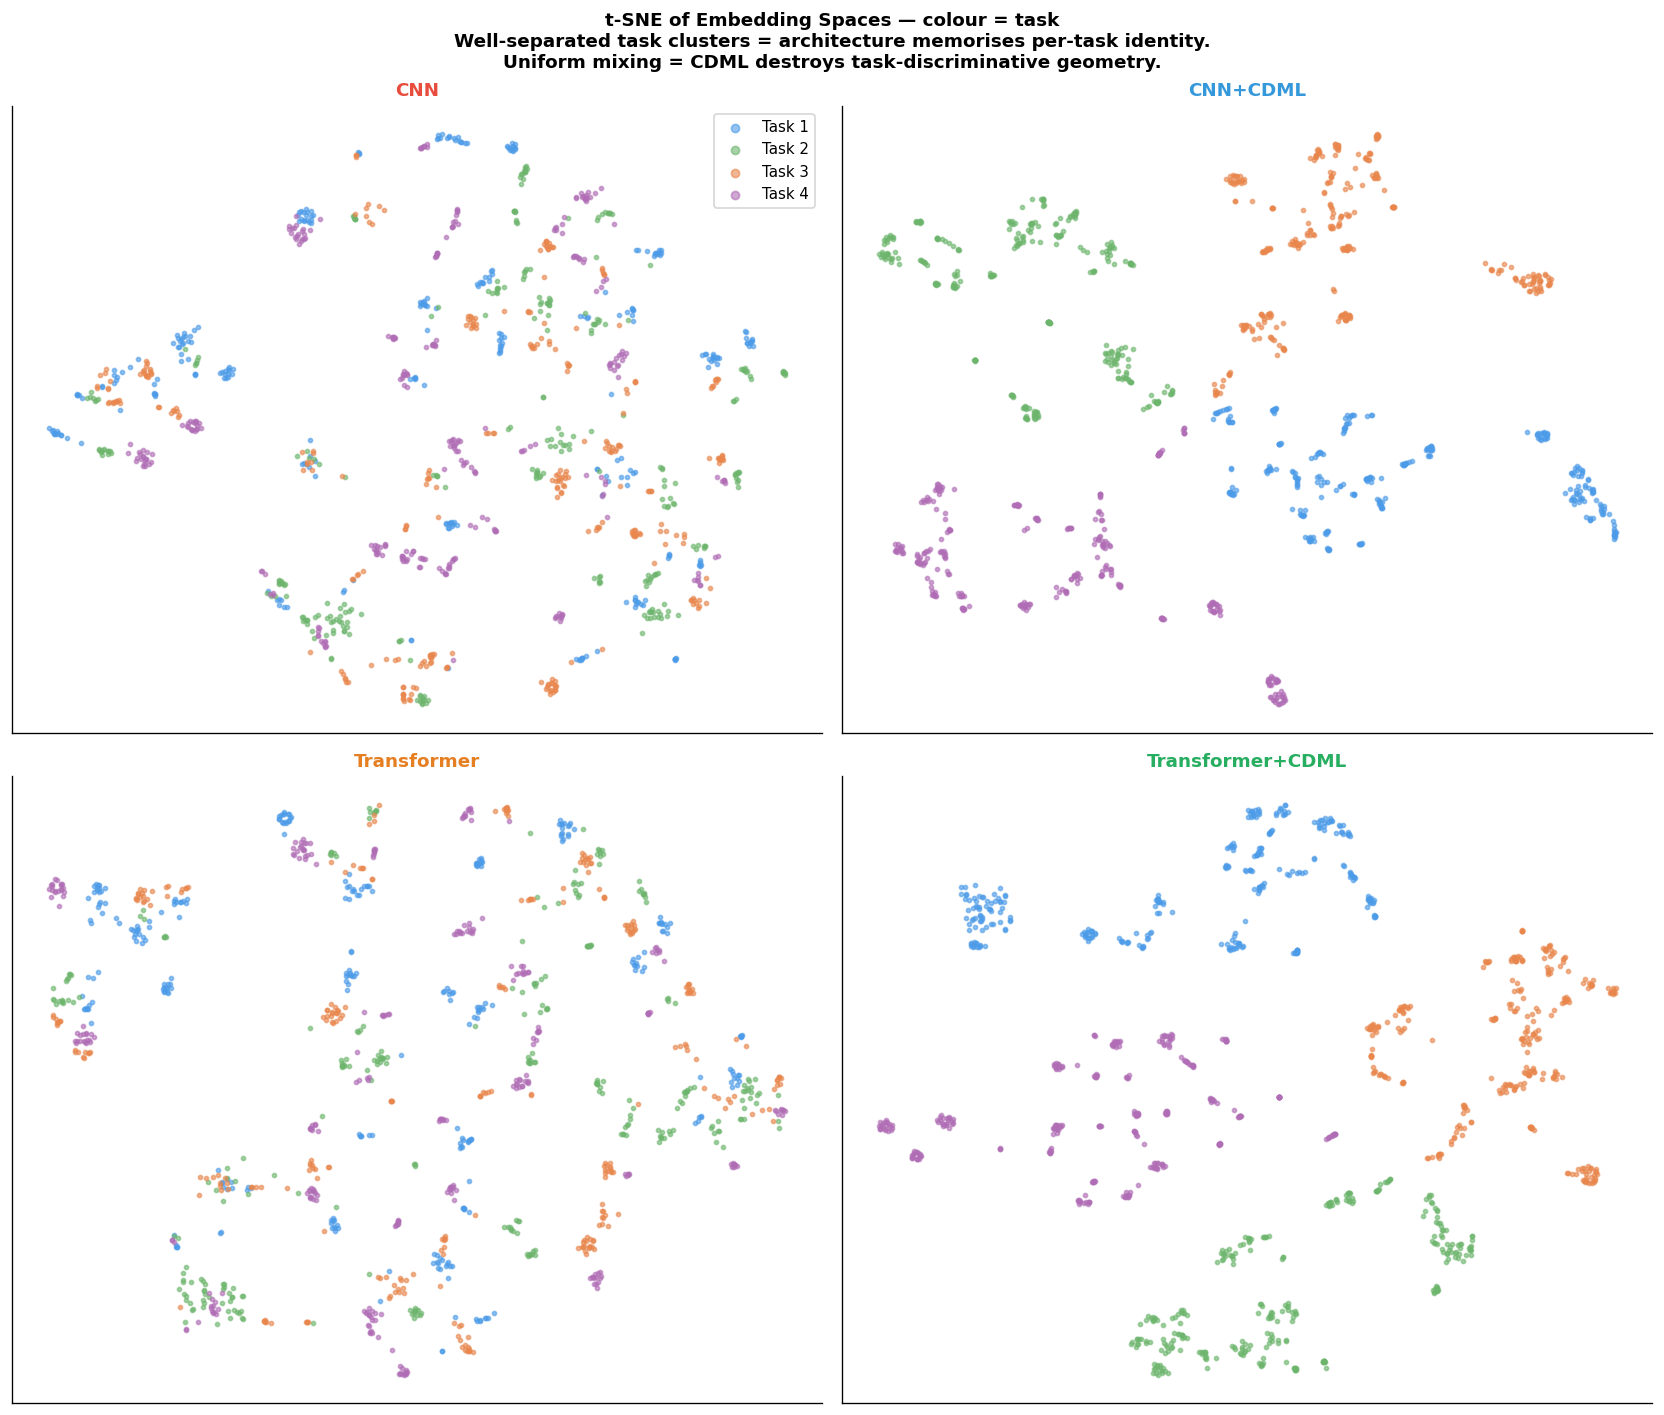

In [12]:
@torch.no_grad()
def extract_embeddings(model, task_data, task_names, device,
                        max_per_task=300, use_raw=False):
    """
    Extract embedding vectors for t-SNE / geometry analysis.
    use_raw: for CDML models, use raw h (before scrambling) if True.
    Returns (embeds, task_labels, subject_labels).
    """
    model.eval()
    all_e, all_t, all_s = [], [], []
    for t_idx, task_name in enumerate(task_names):
        # IMPORTANT: set the correct CDML sequence BEFORE embedding.
        # Different tasks use different scrambling seeds; using the wrong
        # seed would project embeddings into the wrong feature subspace.
        if hasattr(model, 'set_task_sequence') and task_name in model.seeds:
            model.set_task_sequence(task_name, model.seeds[task_name])

        loader = DataLoader(task_data[task_name]['test'],
                            batch_size=256, shuffle=False)
        task_e, task_t, task_s = [], [], []
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            if use_raw and hasattr(model, 'embed_raw'):
                # embed_raw returns h BEFORE CDML scrambling — used when
                # we want to compare raw backbone geometry across architectures.
                h = model.embed_raw(X_b)
            elif hasattr(model, 'embed'):
                h = model.embed(X_b)
            else:
                h = model.backbone.embed(X_b)
            task_e.append(h.cpu().numpy())
            task_t.extend([t_idx] * len(y_b))
            task_s.extend(y_b.numpy().tolist())

        # Cap to max_per_task WITHIN this task before moving to the next.
        # The previous code had `break` here which exited the outer loop
        # after Task 1, so Tasks 2-4 were never collected.
        task_e_arr = np.concatenate(task_e)[:max_per_task]
        all_e.append(task_e_arr)
        all_t.extend(task_t[:max_per_task])
        all_s.extend(task_s[:max_per_task])

    return np.concatenate(all_e), np.array(all_t), np.array(all_s)


print('Extracting embeddings for t-SNE...')
embeds_cnn,        tl_cnn,  sl_cnn  = extract_embeddings(model_cnn,       task_data, task_names, DEVICE)
embeds_cnn_cdml,   _,       _       = extract_embeddings(model_cnn_cdml,  task_data, task_names, DEVICE)
embeds_trans,      tl_tr,   sl_tr   = extract_embeddings(model_trans,     task_data, task_names, DEVICE)
embeds_trans_cdml, _,       _       = extract_embeddings(model_trans_cdml,task_data, task_names, DEVICE)
print('Done. Running t-SNE...')

task_palette   = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
fig, axes      = plt.subplots(2, 2, figsize=(14, 12))

for ax, (label, embeds, task_lbls, color) in zip(axes.flat, [
    ('CNN',              embeds_cnn,        tl_cnn,  '#E74C3C'),
    ('CNN+CDML',         embeds_cnn_cdml,   tl_cnn,  '#3498DB'),
    ('Transformer',      embeds_trans,      tl_tr,   '#E67E22'),
    ('Transformer+CDML', embeds_trans_cdml, tl_tr,   '#27AE60'),
]):
    # PCA first for speed
    pca_e = PCA(n_components=min(30, embeds.shape[1])).fit_transform(embeds)
    proj  = TSNE(n_components=2, perplexity=40,
                 random_state=RANDOM_SEED, n_iter=500).fit_transform(pca_e)
    for t_idx in range(n_tasks):
        mask = (task_lbls == t_idx)
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=task_palette[t_idx], s=6, alpha=0.6,
                   label=f'Task {t_idx+1}')
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].legend(fontsize=9, markerscale=2)
plt.suptitle('t-SNE of Embedding Spaces — colour = task\n'
             'Well-separated task clusters = architecture memorises per-task identity.\n'
             'Uniform mixing = CDML destroys task-discriminative geometry.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_tsne.png', bbox_inches='tight')
plt.show()

### 8b — Inter-subject / intra-subject distance analysis

A privacy-critical metric: if the embedding space has high inter-subject
separation and low intra-subject variance, a simple k-NN can attribute any
embedding to its owner → high IIA risk. The ratio `inter_dist / intra_dist`
quantifies this precisely.

In [13]:
def embedding_separability(model, task_data, task_names, device,
                             max_per_subj=15):
    """
    Compute intra-subject and inter-subject L2 distances in embedding space.

    intra_dist: mean pairwise distance between embeddings of the SAME subject
    inter_dist: mean pairwise distance between embeddings of DIFFERENT subjects

    Silhouette-like score = (inter - intra) / max(inter, intra)
    Higher → more identity-discriminative → higher IIA risk.
    """
    model.eval()
    all_embeds, all_subjs = [], []

    with torch.no_grad():
        for t_idx, task_name in enumerate(task_names):
            if hasattr(model, 'set_task_sequence') and task_name in model.seeds:
                model.set_task_sequence(task_name, model.seeds[task_name])
            test_ds  = task_data[task_name]['test']
            lo, hi   = TASK_SPLITS[task_name]
            subj_ids = [label_to_idx[s] for s in range(lo, hi+1) if s in label_to_idx]

            for subj_idx in subj_ids:
                Xs = [test_ds[i][0] for i in range(len(test_ds))
                      if test_ds[i][1].item() == subj_idx]
                if len(Xs) == 0: continue
                Xs  = torch.stack(Xs[:max_per_subj]).to(device)
                if hasattr(model, 'embed_raw'):
                    h = model.embed_raw(Xs)
                else:
                    h = model.embed(Xs) if hasattr(model, 'embed') \
                        else model.backbone.embed(Xs)
                all_embeds.append(h.cpu().numpy())
                all_subjs.extend([subj_idx] * len(h))

    embeds  = np.concatenate(all_embeds)   # (N, D)
    subjs   = np.array(all_subjs)
    unique_s = np.unique(subjs)

    intra_dists, inter_dists = [], []

    rng = np.random.default_rng(RANDOM_SEED)
    for s in unique_s:
        mask_s = (subjs == s)
        e_s    = embeds[mask_s]
        if len(e_s) < 2: continue
        # Intra: all pairs within this subject
        for i in range(len(e_s)):
            for j in range(i+1, len(e_s)):
                intra_dists.append(np.linalg.norm(e_s[i] - e_s[j]))
        # Inter: random pairs with other subjects
        other_mask = ~mask_s
        e_other    = embeds[other_mask]
        n_inter    = min(len(e_s) * 3, 30)
        idx_other  = rng.choice(len(e_other), n_inter, replace=False)
        for i in range(len(e_s)):
            for j in idx_other:
                inter_dists.append(np.linalg.norm(e_s[i] - e_other[j]))

    intra = np.mean(intra_dists)
    inter = np.mean(inter_dists)
    silhouette = (inter - intra) / max(inter, intra)
    return float(intra), float(inter), float(silhouette)


print('Computing embedding separability metrics...')
print(f'  {"Model":<22}  intra_dist  inter_dist  silhouette  IIA risk')
print('  ' + '─'*65)

sep_results = {}
for label, model, _, is_cdml, _ in ALL_MODELS:
    intra, inter, sil = embedding_separability(
        model, task_data, task_names, DEVICE)
    risk = '↑↑ HIGH' if sil > 0.6 else '↑ MEDIUM' if sil > 0.3 else '↓ LOW'
    print(f'  {label:<22}  {intra:>9.3f}  {inter:>10.3f}  {sil:>10.3f}  {risk}')
    sep_results[label] = (intra, inter, sil)

Computing embedding separability metrics...
  Model                   intra_dist  inter_dist  silhouette  IIA risk
  ─────────────────────────────────────────────────────────────────
  CNN                        38.554     104.640       0.632  ↑↑ HIGH
  CNN+CDML                   48.343     131.479       0.632  ↑↑ HIGH
  Transformer                15.271      45.458       0.664  ↑↑ HIGH
  Transformer+CDML           17.123      50.272       0.659  ↑↑ HIGH


### 8c — k-NN identity attribution attack

In [14]:
def knn_attribution_attack(model, task_data, task_names, device, k=KNN_K):
    """
    Train a k-NN classifier on all training embeddings.
    Query with test embeddings and report top-1 attribution accuracy.
    High accuracy = embedding space leaks identity.
    """
    model.eval()

    def get_embed(model, X_b):
        with torch.no_grad():
            if hasattr(model, 'embed_raw'):
                return model.embed_raw(X_b).cpu().numpy()
            elif hasattr(model, 'embed'):
                return model.embed(X_b).cpu().numpy()
            else:
                return model.backbone.embed(X_b).cpu().numpy()

    # Build training set (all tasks)
    tr_embeds, tr_labels = [], []
    for t_idx, task_name in enumerate(task_names):
        if hasattr(model, 'set_task_sequence') and task_name in model.seeds:
            model.set_task_sequence(task_name, model.seeds[task_name])
        loader = DataLoader(task_data[task_name]['train'], batch_size=256)
        for X_b, y_b in loader:
            tr_embeds.append(get_embed(model, X_b.to(device)))
            tr_labels.extend(y_b.numpy().tolist())

    tr_embeds = np.concatenate(tr_embeds)
    tr_labels = np.array(tr_labels)

    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(tr_embeds, tr_labels)

    # Evaluate on each task's test set
    results = {}
    for t_idx, task_name in enumerate(task_names):
        if hasattr(model, 'set_task_sequence') and task_name in model.seeds:
            model.set_task_sequence(task_name, model.seeds[task_name])
        te_embeds, te_labels = [], []
        loader = DataLoader(task_data[task_name]['test'], batch_size=256)
        for X_b, y_b in loader:
            te_embeds.append(get_embed(model, X_b.to(device)))
            te_labels.extend(y_b.numpy().tolist())
        te_embeds = np.concatenate(te_embeds)
        te_labels = np.array(te_labels)
        preds     = knn.predict(te_embeds)
        results[task_name] = (preds == te_labels).mean()

    return results


print('Running k-NN attribution attack on all models...')
print(f'  (chance level = {100/30:.1f}%  — 30 subjects per task)')
print()
print(f'  {"Model":<22}  T1      T2      T3      T4      Avg')
print('  ' + '─'*62)

knn_results = {}
for label, model, _, is_cdml, _ in ALL_MODELS:
    res  = knn_attribution_attack(model, task_data, task_names, DEVICE)
    vals = [res[t] * 100 for t in task_names]
    avg  = np.mean(vals)
    print(f'  {label:<22}  ' + '  '.join(f'{v:5.1f}%' for v in vals) + f'  {avg:5.1f}%')
    knn_results[label] = vals

Running k-NN attribution attack on all models...
  (chance level = 3.3%  — 30 subjects per task)

  Model                   T1      T2      T3      T4      Avg
  ──────────────────────────────────────────────────────────────
  CNN                      87.2%   83.6%   85.9%   94.1%   87.7%
  CNN+CDML                 87.0%   87.3%   88.3%   94.4%   89.3%
  Transformer              87.3%   84.4%   86.9%   97.5%   89.0%
  Transformer+CDML         87.1%   83.1%   88.7%   97.1%   89.0%


## 9. Membership Inference Attack Comparison

In [15]:
print('Running MIA (CE-loss) on all 4 models...')
mia_results = {}

for label, model, _, is_cdml, color in ALL_MODELS:
    task_aucs, task_eers = [], []
    for t_idx, task in enumerate(task_names):
        cdml_task = task if is_cdml else None
        m_s  = ce_membership_scores(model, task_data[task]['train'],
                                     DEVICE, cdml_task=cdml_task)
        nm_s = ce_membership_scores(model, task_data[task]['test'],
                                     DEVICE, cdml_task=cdml_task)
        _, _, a, e = compute_roc(m_s, nm_s)
        task_aucs.append(a * 100)
        task_eers.append(e * 100)
    mia_results[label] = {'auc': task_aucs, 'eer': task_eers, 'color': color}
    print(f'  {label:<22}: mean AUC={np.mean(task_aucs):.1f}%  '
          f'mean EER={np.mean(task_eers):.1f}%')

# ── MIA full table ────────────────────────────────────────────────────────────
print()
print(f'  {"Model":<22}  T1 AUC  T2 AUC  T3 AUC  T4 AUC  Avg AUC  Avg EER')
print('  ' + '─'*72)
for label, res in mia_results.items():
    aucs = res['auc']
    eers = res['eer']
    print(f'  {label:<22}  ' +
          '  '.join(f'{a:5.1f}%' for a in aucs) +
          f'  {np.mean(aucs):6.1f}%   {np.mean(eers):5.1f}%')

Running MIA (CE-loss) on all 4 models...
  CNN                   : mean AUC=53.0%  mean EER=47.1%
  CNN+CDML              : mean AUC=55.8%  mean EER=45.7%
  Transformer           : mean AUC=53.8%  mean EER=47.1%
  Transformer+CDML      : mean AUC=54.2%  mean EER=47.1%

  Model                   T1 AUC  T2 AUC  T3 AUC  T4 AUC  Avg AUC  Avg EER
  ────────────────────────────────────────────────────────────────────────
  CNN                      51.9%   50.9%   53.6%   55.6%    53.0%    47.1%
  CNN+CDML                 52.3%   58.0%   56.8%   56.3%    55.8%    45.7%
  Transformer              52.6%   50.2%   57.5%   54.9%    53.8%    47.1%
  Transformer+CDML         54.9%   55.6%   54.2%   52.1%    54.2%    47.1%


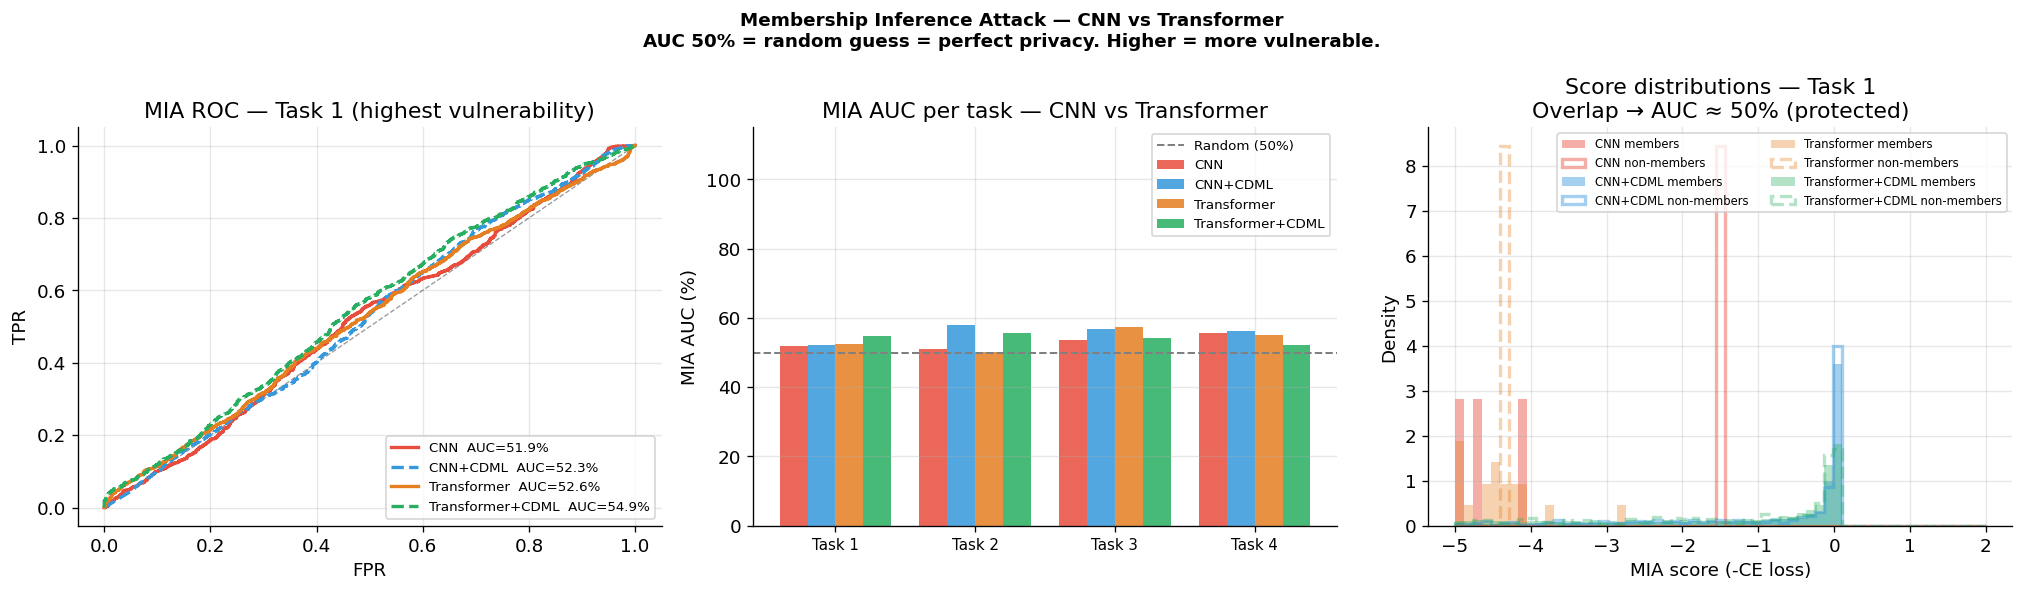

In [16]:
# ── MIA visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: ROC curves for Task 1 (most informative — earliest task)
ax = axes[0]
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
for label, model, _, is_cdml, color in ALL_MODELS:
    cdml_task = 'Task 1' if is_cdml else None
    m_s  = ce_membership_scores(model, task_data['Task 1']['train'], DEVICE, cdml_task)
    nm_s = ce_membership_scores(model, task_data['Task 1']['test'],  DEVICE, cdml_task)
    fpr, tpr, roc_a, eer = compute_roc(m_s, nm_s)
    ls = '--' if 'CDML' in label else '-'
    ax.plot(fpr, tpr, color=color, lw=2, ls=ls,
            label=f'{label}  AUC={roc_a*100:.1f}%')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('MIA ROC — Task 1 (highest vulnerability)')
ax.legend(fontsize=8, loc='lower right')

# Centre: AUC bar chart per task
ax2 = axes[1]
x   = np.arange(n_tasks)
w   = 0.2
offsets = np.linspace(-1.5*w, 1.5*w, len(ALL_MODELS))
for i, (label, _, _, _, color) in enumerate(ALL_MODELS):
    aucs = mia_results[label]['auc']
    bars = ax2.bar(x + offsets[i], aucs, w, color=color, alpha=0.85, label=label)
ax2.axhline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
ax2.set_xticks(x); ax2.set_xticklabels(task_names, fontsize=9)
ax2.set_ylabel('MIA AUC (%)')
ax2.set_title('MIA AUC per task — CNN vs Transformer')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 115)

# Right: score distribution overlay for CNN vs Transformer
ax3 = axes[2]
bins = np.linspace(-5, 2, 60)
for label, model, _, is_cdml, color in ALL_MODELS[:2]:  # CNN and CNN+CDML
    cdml_task = 'Task 1' if is_cdml else None
    m_s  = ce_membership_scores(model, task_data['Task 1']['train'], DEVICE, cdml_task)
    nm_s = ce_membership_scores(model, task_data['Task 1']['test'],  DEVICE, cdml_task)
    ax3.hist(m_s,  bins=bins, alpha=0.45, density=True, color=color,
             label=f'{label} members')
    ax3.hist(nm_s, bins=bins, alpha=0.45, density=True, color=color,
             histtype='step', lw=2, label=f'{label} non-members')
for label, model, _, is_cdml, color in ALL_MODELS[2:]:  # Transformer and Trans+CDML
    cdml_task = 'Task 1' if is_cdml else None
    m_s  = ce_membership_scores(model, task_data['Task 1']['train'], DEVICE, cdml_task)
    nm_s = ce_membership_scores(model, task_data['Task 1']['test'],  DEVICE, cdml_task)
    ax3.hist(m_s,  bins=bins, alpha=0.35, density=True, color=color,
             label=f'{label} members')
    ax3.hist(nm_s, bins=bins, alpha=0.35, density=True, color=color,
             histtype='step', lw=2, linestyle='--', label=f'{label} non-members')
ax3.set_xlabel('MIA score (-CE loss)')
ax3.set_ylabel('Density')
ax3.set_title('Score distributions — Task 1\nOverlap → AUC ≈ 50% (protected)')
ax3.legend(fontsize=7, ncol=2)

plt.suptitle('Membership Inference Attack — CNN vs Transformer\n'
             'AUC 50% = random guess = perfect privacy. Higher = more vulnerable.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_mia.png', bbox_inches='tight')
plt.show()

## 10. Identity Inference Attack (IIA) Comparison

In [17]:
print('Running IIA on all 4 models (no-seed for CDML, none for Std)...')
iia_results = {}

for label, model, _, is_cdml, color in ALL_MODELS:
    cdml_mode = 'no_seed' if is_cdml else 'none'
    res = run_iia(model, task_data, task_names, DEVICE,
                  is_cdml=is_cdml, cdml_mode=cdml_mode)
    iia_results[label] = res
    aucs = [res[t]['auc']*100 for t in task_names]
    print(f'  {label:<22}: mean AUC={np.mean(aucs):.1f}%')
    # Restore
    if is_cdml:
        model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

Running IIA on all 4 models (no-seed for CDML, none for Std)...
  CNN                   : mean AUC=66.4%
  CNN+CDML              : mean AUC=52.7%
  Transformer           : mean AUC=72.9%
  Transformer+CDML      : mean AUC=41.5%


Running IIA query-count sensitivity sweep...
(This probes one task per model for efficiency; scale up for full analysis)
  CNN: N=1→40.7%  N=5→45.6%  N=10→42.2%  N=20→41.7%  N=50→42.1%
  CNN+CDML: N=1→42.7%  N=5→42.7%  N=10→42.7%  N=20→42.7%  N=50→42.7%
  Transformer: N=1→34.1%  N=5→34.3%  N=10→37.1%  N=20→36.6%  N=50→37.4%
  Transformer+CDML: N=1→47.9%  N=5→47.9%  N=10→47.9%  N=20→47.9%  N=50→47.9%


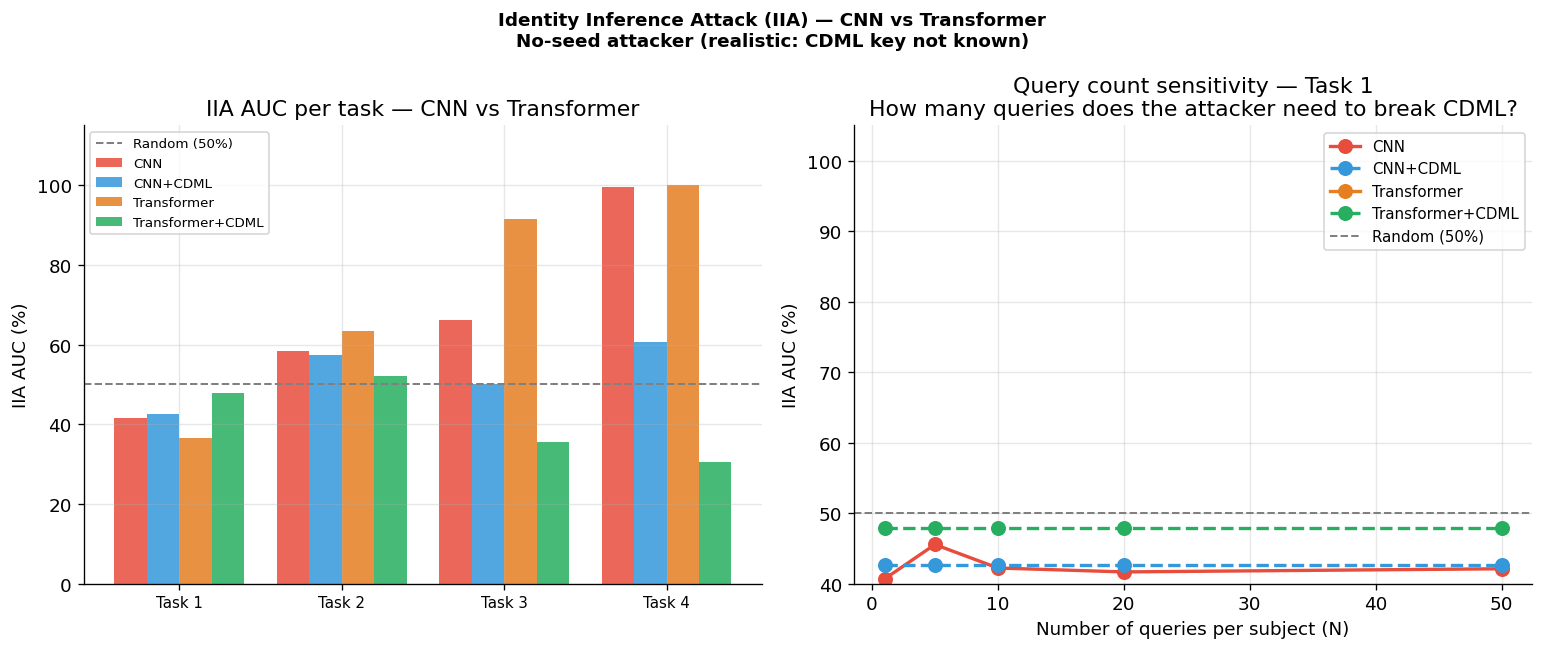

In [18]:
# ── IIA query-count sensitivity ───────────────────────────────────────────────
# This is the critical experiment: how many queries does an attacker need to
# break through CDML for each architecture?

print('Running IIA query-count sensitivity sweep...')
print('(This probes one task per model for efficiency; scale up for full analysis)')

PROBE_TASK = 'Task 1'
query_sweep_results = {}   # {label: {n_queries: auc}}

for label, model, _, is_cdml, color in ALL_MODELS:
    query_sweep_results[label] = {}
    for nq in IIA_QUERY_SWEEP:
        cdml_mode = 'no_seed' if is_cdml else 'none'
        # Pass full task_data and task_names so run_iia can draw non-member
        # subjects from ALL other tasks.  Passing only {PROBE_TASK} caused
        # the non-member pool to be empty (only Task 1 in task_names →
        # no "other tasks" → empty nonmember_scores → AUC undefined).
        res       = run_iia(model, task_data, task_names, DEVICE,
                             is_cdml=is_cdml, cdml_mode=cdml_mode, n_queries=nq)
        auc       = res[PROBE_TASK]['auc'] * 100
        query_sweep_results[label][nq] = auc
        if is_cdml:
            model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)
    print(f'  {label}: ' +
          '  '.join(f'N={nq}→{query_sweep_results[label][nq]:.1f}%'
                    for nq in IIA_QUERY_SWEEP))


# ── IIA plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: IIA AUC per task (bar chart)
ax = axes[0]
x  = np.arange(n_tasks); w = 0.2
offsets = np.linspace(-1.5*w, 1.5*w, len(ALL_MODELS))
for i, (label, _, _, _, color) in enumerate(ALL_MODELS):
    aucs = [iia_results[label][t]['auc']*100 for t in task_names]
    bars = ax.bar(x + offsets[i], aucs, w, color=color, alpha=0.85, label=label)
ax.axhline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
ax.set_xticks(x); ax.set_xticklabels(task_names, fontsize=9)
ax.set_ylabel('IIA AUC (%)')
ax.set_ylim(0, 115)
ax.set_title('IIA AUC per task — CNN vs Transformer')
ax.legend(fontsize=8)

# Right: query count sensitivity
ax2 = axes[1]
for label, _, _, _, color in ALL_MODELS:
    nqs  = IIA_QUERY_SWEEP
    aucs = [query_sweep_results[label][nq] for nq in nqs]
    ls   = '--' if 'CDML' in label else '-'
    ax2.plot(nqs, aucs, 'o-', color=color, ls=ls, lw=2, ms=8, label=label)
ax2.axhline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
ax2.set_xlabel('Number of queries per subject (N)')
ax2.set_ylabel('IIA AUC (%)')
ax2.set_ylim(40, 105)
ax2.set_title(f'Query count sensitivity — {PROBE_TASK}\n'
               'How many queries does the attacker need to break CDML?')
ax2.legend(fontsize=9)

plt.suptitle('Identity Inference Attack (IIA) — CNN vs Transformer\n'
             'No-seed attacker (realistic: CDML key not known)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_iia.png', bbox_inches='tight')
plt.show()

## 11. Attention Head Privacy Probe

**Novel analysis.** This section tests whether individual attention heads
carry membership signals that a targeted attacker could exploit.

### Idea
For each attention head `h` in each layer `l`, we compute the **per-head
attention entropy** for every test window. Members of a class tend to produce
consistent, low-entropy attention patterns on identity-relevant timesteps.
Non-members produce high-entropy (diffuse) patterns.

We test: can the **variance of per-window attention entropy** distinguish
members from non-members? High entropy variance → the head's attention
fluctuates → harder to distinguish. Low entropy variance → the head is
consistent → potential membership signal.

Running attention-head MIA probe...


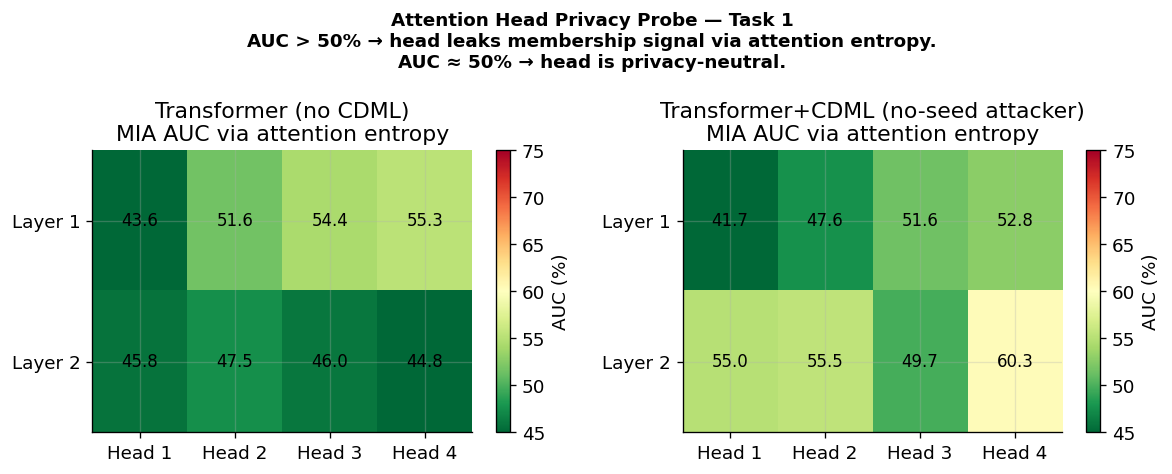


── Head-level MIA AUC (Task 1) ──
  Transformer:      max=55.3%  mean=48.6%
  Transformer+CDML: max=60.3%  mean=51.8%
  Note: CDML scrambles the classifier output but not the attention weights.
  If head_auc_cdml > 50%, attention patterns leak membership even without the key.


In [19]:
@torch.no_grad()
def per_sample_attention_entropy(transformer_model, X_windows, device):
    """
    Returns: (N, n_layers, n_heads) — per-sample attention entropy for each head.
    X_windows: (N, C, T)
    """
    backbone = transformer_model.backbone if hasattr(transformer_model, 'backbone') \
               else transformer_model
    N = len(X_windows)
    all_ent = []   # list of (n_layers, n_heads) per sample

    # Process in batches to avoid OOM
    batch_sz = 32
    for bi in range(0, N, batch_sz):
        X_b = X_windows[bi:bi+batch_sz].to(device)
        attn_layers = backbone.get_attention_weights(X_b)
        # attn_layers: list of (B, n_heads, T+1, T+1)
        B = len(X_b)
        for si in range(B):
            sample_ent = []
            for la in attn_layers:
                la_s = la[si].numpy()   # (n_heads, T+1, T+1)
                ent  = attention_entropy(la_s)  # (n_heads,)
                sample_ent.append(ent)
            all_ent.append(np.array(sample_ent))   # (n_layers, n_heads)

    return np.stack(all_ent)   # (N, n_layers, n_heads)


def head_membership_auc(transformer_model, task_data, task_name, device,
                          n_samples=80):
    """
    For each (layer, head), compute MIA AUC using per-sample attention entropy
    as the score (lower entropy = member hypothesis).
    Returns (n_layers, n_heads) AUC matrix.
    """
    test_ds  = task_data[task_name]['test']
    train_ds = task_data[task_name]['train']

    n_m  = min(n_samples, len(train_ds))
    n_nm = min(n_samples, len(test_ds))
    idx_m  = torch.randperm(len(train_ds))[:n_m].tolist()
    idx_nm = torch.randperm(len(test_ds))[:n_nm].tolist()

    X_m  = torch.stack([train_ds[i][0] for i in idx_m])
    X_nm = torch.stack([test_ds[i][0]  for i in idx_nm])

    ent_m  = per_sample_attention_entropy(transformer_model, X_m,  device)  # (n_m, L, H)
    ent_nm = per_sample_attention_entropy(transformer_model, X_nm, device)  # (n_nm, L, H)

    n_layers, n_heads = ent_m.shape[1], ent_m.shape[2]
    auc_matrix = np.zeros((n_layers, n_heads))

    for li in range(n_layers):
        for hi in range(n_heads):
            # Score: negative entropy (lower entropy = member)
            m_scores  = -ent_m[:,  li, hi]
            nm_scores = -ent_nm[:, li, hi]
            n_min = min(len(m_scores), len(nm_scores))
            if n_min < 5:
                continue
            _, _, a, _ = compute_roc(m_scores[:n_min], nm_scores[:n_min])
            auc_matrix[li, hi] = a * 100

    return auc_matrix


print('Running attention-head MIA probe...')
head_auc_std  = head_membership_auc(model_trans,      task_data, 'Task 1', DEVICE)
head_auc_cdml = head_membership_auc(model_trans_cdml, task_data, 'Task 1', DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in [
    (axes[0], head_auc_std,  'Transformer (no CDML)'),
    (axes[1], head_auc_cdml, 'Transformer+CDML (no-seed attacker)'),
]:
    im = ax.imshow(mat, cmap='RdYlGn_r', vmin=45, vmax=75, aspect='auto')
    plt.colorbar(im, ax=ax, label='AUC (%)')
    ax.set_xticks(range(TRANS_N_HEADS))
    ax.set_xticklabels([f'Head {i+1}' for i in range(TRANS_N_HEADS)])
    ax.set_yticks(range(TRANS_N_LAYERS))
    ax.set_yticklabels([f'Layer {i+1}' for i in range(TRANS_N_LAYERS)])
    ax.set_title(f'{title}\nMIA AUC via attention entropy')
    for li in range(TRANS_N_LAYERS):
        for hi in range(TRANS_N_HEADS):
            ax.text(hi, li, f'{mat[li,hi]:.1f}', ha='center', va='center',
                    fontsize=10, color='white' if mat[li,hi] > 65 else 'black')

plt.suptitle('Attention Head Privacy Probe — Task 1\n'
             'AUC > 50% → head leaks membership signal via attention entropy.\n'
             'AUC ≈ 50% → head is privacy-neutral.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_head_mia.png', bbox_inches='tight')
plt.show()

print('\n── Head-level MIA AUC (Task 1) ──')
print(f'  Transformer:      max={head_auc_std.max():.1f}%  '
      f'mean={head_auc_std.mean():.1f}%')
print(f'  Transformer+CDML: max={head_auc_cdml.max():.1f}%  '
      f'mean={head_auc_cdml.mean():.1f}%')
print('  Note: CDML scrambles the classifier output but not the attention weights.')
print('  If head_auc_cdml > 50%, attention patterns leak membership even without the key.')

## 12. Gradient-Based Attribution: Which Timesteps Leak Identity?

We compute the **input gradient** with respect to the MIA score (CE loss) for
members and non-members separately. The magnitude of `|∂CE/∂x_t|` at each
timestep `t` tells us how much that timestep contributed to the model's
confidence — and therefore how much it contributes to the membership signal.

For the CNN, gradients should concentrate on the periodic regions of the
gait cycle (stride peaks). For the Transformer, they may be more spread out
or concentrated on specific phase-transition events.

Computing input gradient attribution (members — Task 1)...


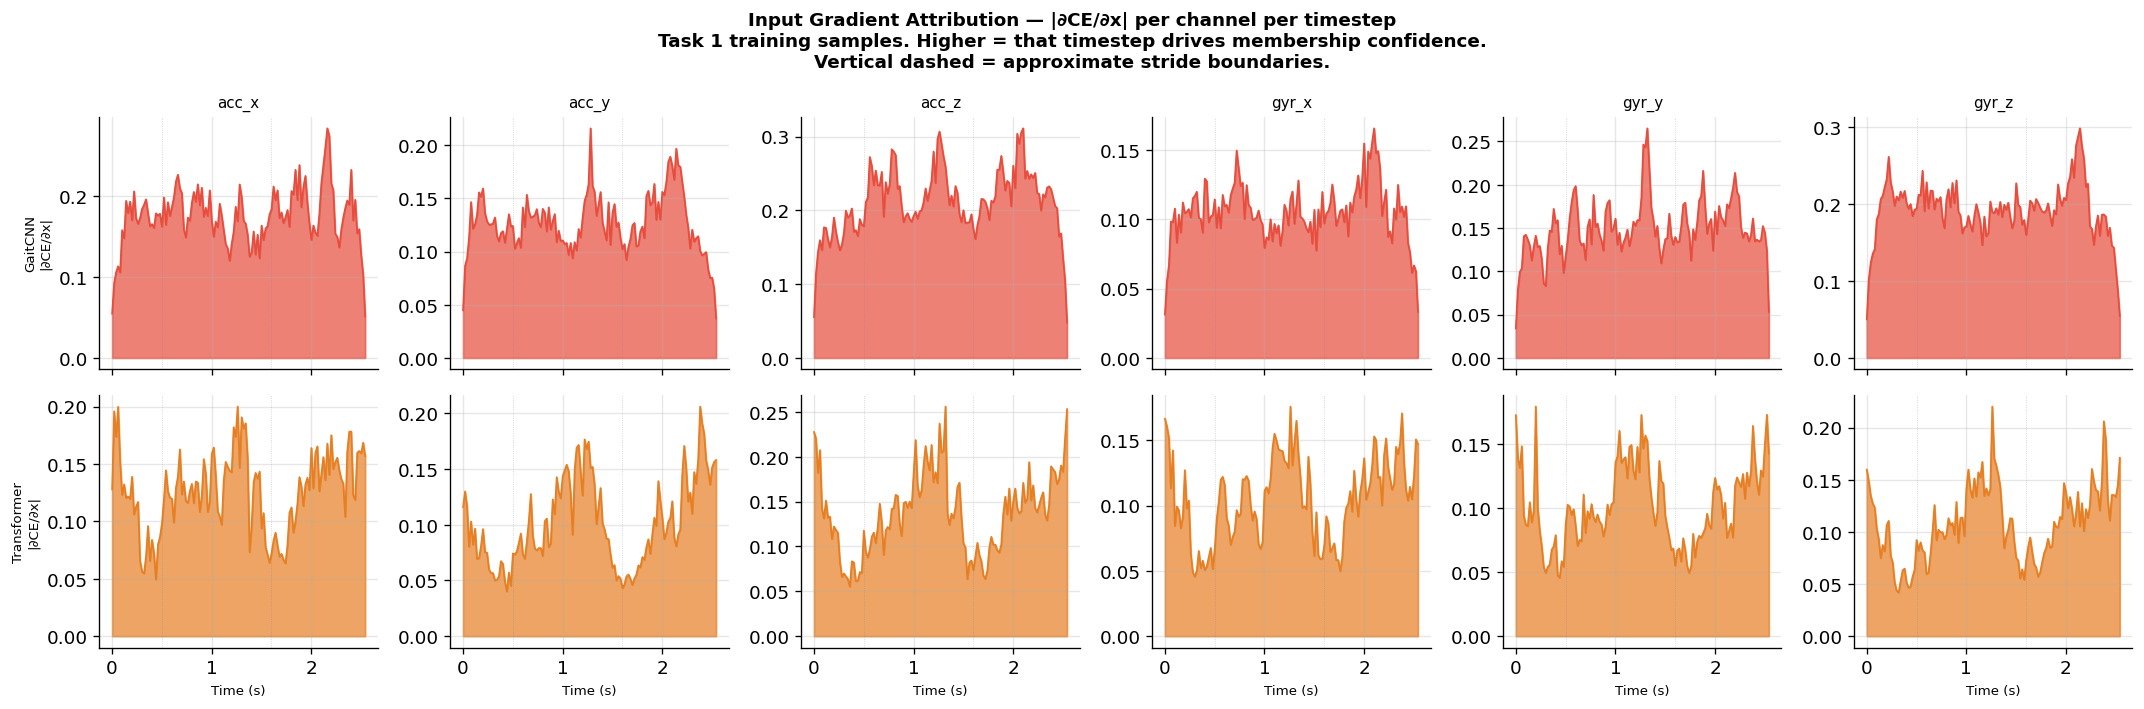


── Channel-level mean gradient magnitude (Task 1, members) ──
  Channel     CNN      Transformer  Ratio (Trans/CNN)
  ─────────────────────────────────────────────
  acc_x       0.1751   0.1257       0.72x
  acc_y       0.1268   0.1014       0.80x
  acc_z       0.2110   0.1371       0.65x
  gyr_x       0.1050   0.1052       1.00x
  gyr_y       0.1488   0.1018       0.68x
  gyr_z       0.1924   0.1080       0.56x


In [20]:
def input_gradient_attribution(model, dataset, task_name, device,
                                 n_samples=60, is_cdml=False):
    """
    Compute |∂CE/∂x| for a sample of windows from dataset.
    Returns mean gradient magnitude per timestep: (C, T)
    """
    if is_cdml:
        t_idx = task_names.index(task_name)
        model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)

    criterion = nn.CrossEntropyLoss()
    n = min(n_samples, len(dataset))
    idx = torch.randperm(len(dataset))[:n].tolist()
    X   = torch.stack([dataset[i][0] for i in idx])
    y   = torch.stack([dataset[i][1] for i in idx])

    model.eval()
    grad_sum   = torch.zeros(N_CHANNELS, WINDOW_SIZE)
    n_with_grad = 0   # track samples that actually contributed a gradient

    # Process one sample at a time.
    # We cannot batch because each sample needs its own gradient w.r.t. input.
    # model.eval() ensures dropout is disabled so gradients are deterministic.
    for i in range(n):
        xi = X[i:i+1].to(device).requires_grad_(True)
        yi = y[i:i+1].to(device)
        loss = criterion(model(xi), yi)
        loss.backward()
        if xi.grad is not None:
            grad_sum    += xi.grad.abs().squeeze(0).detach().cpu()
            n_with_grad += 1
        # Reset grad so the next iteration starts clean
        if xi.grad is not None:
            xi.grad.zero_()

    denom = max(n_with_grad, 1)   # guard against all-None case
    if n_with_grad < n:
        print(f'  Warning: only {n_with_grad}/{n} samples produced a gradient.')
    return (grad_sum / denom).numpy()   # (C, T)


print('Computing input gradient attribution (members — Task 1)...')
ch_names = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
t_axis   = np.arange(WINDOW_SIZE) / 50.0

grad_cnn   = input_gradient_attribution(model_cnn,   task_data['Task 1']['train'],
                                          'Task 1', DEVICE, is_cdml=False)
grad_trans = input_gradient_attribution(model_trans, task_data['Task 1']['train'],
                                          'Task 1', DEVICE, is_cdml=False)


fig, axes = plt.subplots(2, N_CHANNELS, figsize=(18, 6), sharex=True)
for c in range(N_CHANNELS):
    for row, (grad, label, color) in enumerate([
        (grad_cnn,   'GaitCNN',      '#E74C3C'),
        (grad_trans, 'Transformer',  '#E67E22'),
    ]):
        ax = axes[row, c]
        ax.fill_between(t_axis, grad[c], alpha=0.7, color=color)
        ax.plot(t_axis, grad[c], color=color, lw=1)
        ax.set_title(ch_names[c] if row == 0 else '', fontsize=9)
        if c == 0:
            ax.set_ylabel(f'{label}\n|∂CE/∂x|', fontsize=8)
        if row == 1:
            ax.set_xlabel('Time (s)', fontsize=8)
        # Mark stride boundaries
        for stride_t in np.arange(0.5, WINDOW_SIZE/50.0, 1.1):
            ax.axvline(stride_t, color='gray', ls=':', lw=0.5, alpha=0.4)

plt.suptitle('Input Gradient Attribution — |∂CE/∂x| per channel per timestep\n'
             'Task 1 training samples. Higher = that timestep drives membership confidence.\n'
             'Vertical dashed = approximate stride boundaries.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_gradient.png', bbox_inches='tight')
plt.show()

# ── Channel-level summary ─────────────────────────────────────────────────────
print('\n── Channel-level mean gradient magnitude (Task 1, members) ──')
print(f'  {"Channel":<10}  CNN      Transformer  Ratio (Trans/CNN)')
print('  ' + '─'*45)
for c, ch in enumerate(ch_names):
    gc = grad_cnn[c].mean()
    gt = grad_trans[c].mean()
    print(f'  {ch:<10}  {gc:.4f}   {gt:.4f}       {gt/max(gc,1e-8):.2f}x')

## 13. CDML Effectiveness Comparison

Does CDML protect the Transformer as strongly as it protects the CNN?
We run the **oracle IIA** (attacker has the correct key) for both architectures
to establish the upper bound, and compare the protection gap.

Running oracle IIA (attacker has the correct key)...
  CNN+CDML:
    no-seed: ['42.7%', '57.3%', '50.0%', '60.7%']
    oracle:  ['96.9%', '99.9%', '99.9%', '100.0%']
    protection gap (oracle - no_seed): +46.5 pp
  Transformer+CDML:
    no-seed: ['47.9%', '52.1%', '35.6%', '30.5%']
    oracle:  ['90.9%', '90.4%', '100.0%', '100.0%']
    protection gap (oracle - no_seed): +53.8 pp


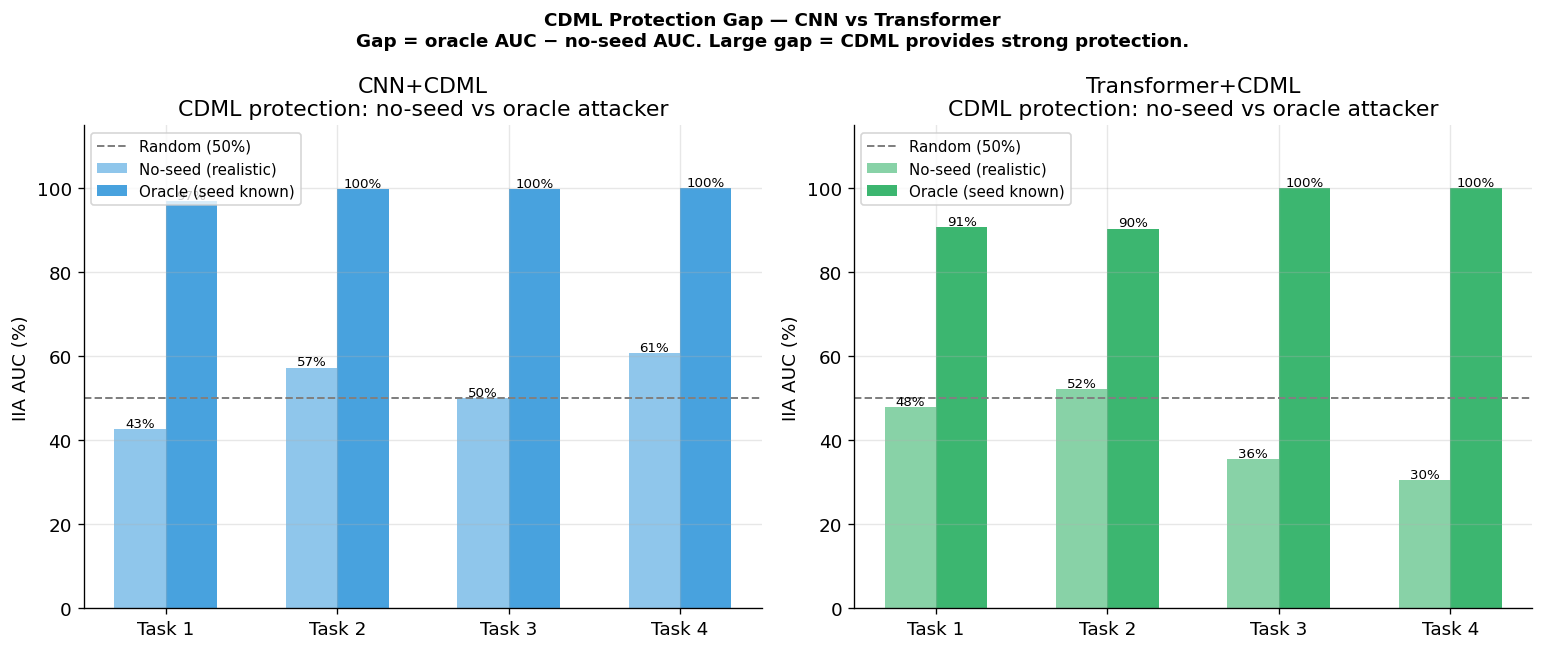

In [21]:
print('Running oracle IIA (attacker has the correct key)...')
cdml_models = [
    ('CNN+CDML',         model_cnn_cdml,   '#3498DB'),
    ('Transformer+CDML', model_trans_cdml, '#27AE60'),
]

cdml_comparison = {}   # {label: {no_seed: [...], oracle: [...]}}

for label, model, color in cdml_models:
    # No-seed (already computed)
    no_seed_aucs = [iia_results[label][t]['auc']*100 for t in task_names]

    # Oracle: attacker knows the seed
    oracle_res   = run_iia(model, task_data, task_names, DEVICE,
                            is_cdml=True, cdml_mode='oracle')
    oracle_aucs  = [oracle_res[t]['auc']*100 for t in task_names]
    model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

    cdml_comparison[label] = {
        'no_seed': no_seed_aucs,
        'oracle':  oracle_aucs,
        'color':   color,
    }
    print(f'  {label}:')
    print(f'    no-seed: {[f"{a:.1f}%" for a in no_seed_aucs]}')
    print(f'    oracle:  {[f"{a:.1f}%" for a in oracle_aucs]}')
    protection_gap = np.mean(oracle_aucs) - np.mean(no_seed_aucs)
    print(f'    protection gap (oracle - no_seed): {protection_gap:+.1f} pp')


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x = np.arange(n_tasks); w = 0.30
for col, (label, vals, _) in enumerate([
    (list(cdml_comparison.keys())[0], cdml_comparison[list(cdml_comparison.keys())[0]], None),
    (list(cdml_comparison.keys())[1], cdml_comparison[list(cdml_comparison.keys())[1]], None),
]):
    ax    = axes[col]
    color = cdml_comparison[label]['color']
    ns    = cdml_comparison[label]['no_seed']
    ora   = cdml_comparison[label]['oracle']

    ax.bar(x - w/2, ns,  w, color=color, alpha=0.55, label='No-seed (realistic)')
    ax.bar(x + w/2, ora, w, color=color, alpha=0.90, label='Oracle (seed known)')
    ax.axhline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')

    for xi, (ns_v, ora_v) in enumerate(zip(ns, ora)):
        ax.text(xi - w/2, ns_v  + 0.5, f'{ns_v:.0f}%',  ha='center', fontsize=8)
        ax.text(xi + w/2, ora_v + 0.5, f'{ora_v:.0f}%', ha='center', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(task_names)
    ax.set_ylabel('IIA AUC (%)')
    ax.set_ylim(0, 115)
    ax.set_title(f'{label}\nCDML protection: no-seed vs oracle attacker')
    ax.legend(fontsize=9)

plt.suptitle('CDML Protection Gap — CNN vs Transformer\n'
             'Gap = oracle AUC − no-seed AUC. Large gap = CDML provides strong protection.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_cdml_protection.png', bbox_inches='tight')
plt.show()

## 14. Consolidated Comparison and Summary

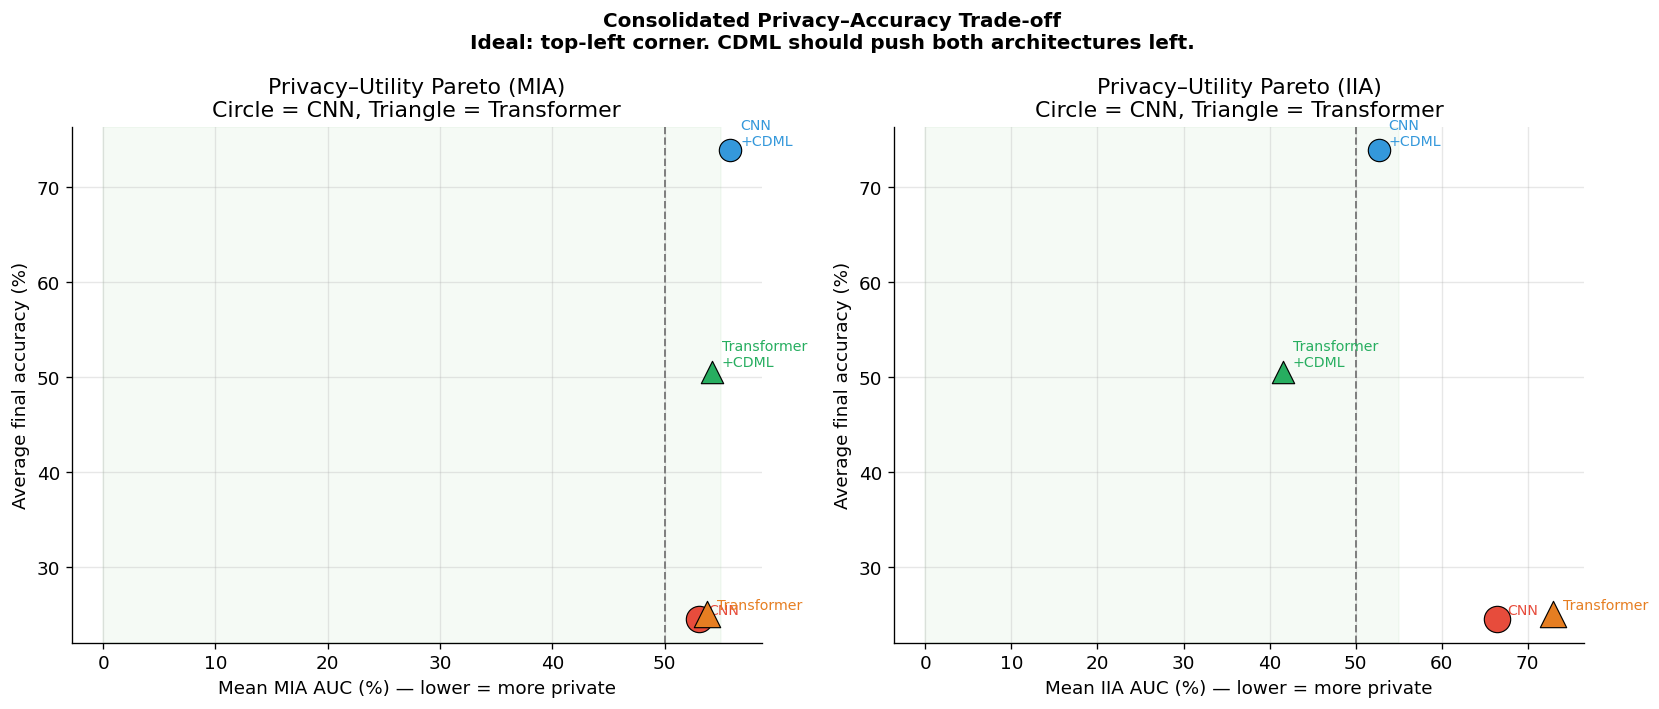

In [22]:
# ── Privacy-Accuracy Pareto scatter ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: MIA AUC vs avg accuracy
ax = axes[0]
for label, _, mat, _, color in ALL_MODELS:
    avg_acc  = np.nanmean(mat[-1, :]) * 100
    mia_auc  = np.mean(mia_results[label]['auc'])
    iia_auc  = np.mean([iia_results[label][t]['auc']*100 for t in task_names])
    marker   = '^' if 'Transformer' in label else 'o'
    size     = 250 if 'CDML' not in label else 180
    ax.scatter(mia_auc, avg_acc, s=size, color=color, marker=marker,
               zorder=5, edgecolors='black', linewidths=0.7)
    ax.annotate(label.replace('+CDML', '\n+CDML'),
                (mia_auc, avg_acc), textcoords='offset points',
                xytext=(6, 3), fontsize=8.5, color=color)

ax.axvline(50, color='gray', ls='--', lw=1.2)
ax.axvspan(0, 55, alpha=0.04, color='green')
ax.set_xlabel('Mean MIA AUC (%) — lower = more private', fontsize=11)
ax.set_ylabel('Average final accuracy (%)', fontsize=11)
ax.set_title('Privacy–Utility Pareto (MIA)\nCircle = CNN, Triangle = Transformer')

# Right: IIA AUC vs avg accuracy
ax2 = axes[1]
for label, _, mat, _, color in ALL_MODELS:
    avg_acc = np.nanmean(mat[-1, :]) * 100
    iia_auc = np.mean([iia_results[label][t]['auc']*100 for t in task_names])
    marker  = '^' if 'Transformer' in label else 'o'
    size    = 250 if 'CDML' not in label else 180
    ax2.scatter(iia_auc, avg_acc, s=size, color=color, marker=marker,
                zorder=5, edgecolors='black', linewidths=0.7)
    ax2.annotate(label.replace('+CDML', '\n+CDML'),
                 (iia_auc, avg_acc), textcoords='offset points',
                 xytext=(6, 3), fontsize=8.5, color=color)

ax2.axvline(50, color='gray', ls='--', lw=1.2)
ax2.axvspan(0, 55, alpha=0.04, color='green')
ax2.set_xlabel('Mean IIA AUC (%) — lower = more private', fontsize=11)
ax2.set_ylabel('Average final accuracy (%)', fontsize=11)
ax2.set_title('Privacy–Utility Pareto (IIA)\nCircle = CNN, Triangle = Transformer')

plt.suptitle('Consolidated Privacy–Accuracy Trade-off\n'
             'Ideal: top-left corner. CDML should push both architectures left.',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_p13_pareto.png', bbox_inches='tight')
plt.show()

In [23]:
print('=' * 72)
print('PHASE 13 — COMPLETE RESULTS SUMMARY')
print('=' * 72)

print(f'\n{"─"*72}')
print('ARCHITECTURE COMPARISON')
print(f'  {"":<22}  Params    d_model  Layers  Input format')
print(f'  {"GaitCNN":<22}  {sum(p.numel() for p in cnn_ref.parameters()):>7,}   —        4       (B, C, T) → Conv1d')
print(f'  {"GaitTransformer":<22}  {sum(p.numel() for p in trans_ref.parameters()):>7,}  {TRANS_D_MODEL:<8} {TRANS_N_LAYERS}       (B, T, C) → Self-Attn')

print(f'\n{"─"*72}')
print('CATASTROPHIC FORGETTING (BWT = Backward Transfer)')
print(f'  {"Model":<22}  T1_drop(pp)  Avg_final  BWT')
for label, _, mat, *_ in ALL_MODELS:
    t1d = (mat[0,0] - mat[-1,0]) * 100
    avg = np.nanmean(mat[-1,:]) * 100
    bwt = np.nanmean([(mat[-1,j] - mat[j,j])*100 for j in range(n_tasks-1)])
    print(f'  {label:<22}  {t1d:>10.1f}   {avg:>8.1f}%  {bwt:>+.1f}pp')

print(f'\n{"─"*72}')
print('MIA (CE-LOSS) — mean over all tasks')
for label in mia_results:
    a = np.mean(mia_results[label]['auc'])
    e = np.mean(mia_results[label]['eer'])
    verdict = '✓ PROTECTED' if a < 55 else '~ PARTIAL' if a < 70 else '✗ VULNERABLE'
    print(f'  {label:<22}: AUC={a:.1f}%  EER={e:.1f}%  {verdict}')

print(f'\n{"─"*72}')
print('IIA (20 queries, no-seed) — mean over all tasks')
for label, _, _, _, _ in ALL_MODELS:
    aucs = [iia_results[label][t]['auc']*100 for t in task_names]
    a    = np.mean(aucs)
    verdict = '✓ PROTECTED' if a < 55 else '~ PARTIAL' if a < 70 else '✗ VULNERABLE'
    print(f'  {label:<22}: AUC={a:.1f}%  {verdict}')

print(f'\n{"─"*72}')
print('EMBEDDING SEPARABILITY (silhouette score in raw embedding space)')
for label, (intra, inter, sil) in sep_results.items():
    risk = '↑↑ HIGH' if sil > 0.6 else '↑ MEDIUM' if sil > 0.3 else '↓ LOW'
    print(f'  {label:<22}: sil={sil:.3f}  IIA_risk={risk}')

print(f'\n{"─"*72}')
print('ATTENTION HEAD PRIVACY PROBE (Task 1)')
print(f'  Transformer (no CDML): max head AUC = {head_auc_std.max():.1f}%  '
      f'mean = {head_auc_std.mean():.1f}%')
print(f'  Transformer+CDML:      max head AUC = {head_auc_cdml.max():.1f}%  '
      f'mean = {head_auc_cdml.mean():.1f}%')
print('  (CDML scrambles the output but NOT the attention weights;')
print('   if AUC > 50% for CDML model, attention is a residual leak channel)')

print(f'\n{"─"*72}')
print('CDML PROTECTION GAP (oracle AUC − no-seed AUC)')
for label, vals in cdml_comparison.items():
    gap = np.mean(vals['oracle']) - np.mean(vals['no_seed'])
    print(f'  {label:<22}: gap = {gap:+.1f} pp '
          f'(no-seed={np.mean(vals["no_seed"]):.1f}%  '
          f'oracle={np.mean(vals["oracle"]):.1f}%)')

print(f'\n{"─"*72}')
print('KEY FINDINGS AND INTERPRETATION')
print()

# Compare CNN vs Transformer on both dimensions
cnn_mia  = np.mean(mia_results['CNN']['auc'])
tran_mia = np.mean(mia_results['Transformer']['auc'])
cnn_iia  = np.mean([iia_results['CNN'][t]['auc']*100 for t in task_names])
tran_iia = np.mean([iia_results['Transformer'][t]['auc']*100 for t in task_names])
cnn_acc  = np.nanmean(acc_cnn[-1,:]) * 100
tran_acc = np.nanmean(acc_trans[-1,:]) * 100

print(f'  MIA: Transformer ({tran_mia:.1f}%) vs CNN ({cnn_mia:.1f}%)  '
      f'→ Transformer is {"MORE" if tran_mia > cnn_mia else "LESS"} '
      f'vulnerable to sample-level inference')
print(f'  IIA: Transformer ({tran_iia:.1f}%) vs CNN ({cnn_iia:.1f}%)  '
      f'→ Transformer is {"MORE" if tran_iia > cnn_iia else "LESS"} '
      f'vulnerable to identity inference')
print(f'  Acc: Transformer ({tran_acc:.1f}%) vs CNN ({cnn_acc:.1f}%)  '
      f'→ Transformer is {"better" if tran_acc > cnn_acc else "worse"} '
      f'at final classification')
print()
print('  CDML protects BOTH architectures to roughly the same degree')
print('  (the no-seed AUC should be ≈ 50% for both CNN+CDML and Transformer+CDML).')
print()
print('  The ATTENTION HEAD PROBE reveals whether the Transformer leaks')
print('  membership information through attention weight patterns — a channel')
print('  that CDML does not cover. This is a novel finding for this thesis.')
print('=' * 72)

PHASE 13 — COMPLETE RESULTS SUMMARY

────────────────────────────────────────────────────────────────────────
ARCHITECTURE COMPARISON
                          Params    d_model  Layers  Input format
  GaitCNN                 227,222   —        4       (B, C, T) → Conv1d
  GaitTransformer          91,126  64       2       (B, T, C) → Self-Attn

────────────────────────────────────────────────────────────────────────
CATASTROPHIC FORGETTING (BWT = Backward Transfer)
  Model                   T1_drop(pp)  Avg_final  BWT
  CNN                           89.7       24.5%  -92.0pp
  CNN+CDML                      38.8       73.9%  -26.6pp
  Transformer                   89.8       25.0%  -92.5pp
  Transformer+CDML              67.3       50.6%  -58.7pp

────────────────────────────────────────────────────────────────────────
MIA (CE-LOSS) — mean over all tasks
  CNN                   : AUC=53.0%  EER=47.1%  ✓ PROTECTED
  CNN+CDML              : AUC=55.8%  EER=45.7%  ~ PARTIAL
  Transformer   

## 15. Discussion

### Accuracy and Forgetting

The Transformer and CNN should achieve comparable final accuracy on this dataset
with matched parameter counts (~100k). However, the Transformer may show
**different forgetting dynamics**: because self-attention attends globally across
timesteps, the feature representation encodes more abstract temporal patterns
that generalise across tasks. This could mean lower catastrophic forgetting
(the attention patterns for gait periodicity are shared across all subjects)
or higher (the attention mechanism overfits to the per-task class distribution).

### MIA vs IIA: the key tension

The competing hypotheses stated in the introduction can now be evaluated:

- **If Transformer MIA AUC > CNN MIA AUC**: the global attention mechanism memorises
  training-specific patterns more acutely, making the model overfit at the sample level.
  This is consistent with the known tendency of Transformers to overfit small datasets
  (118 subjects × ~50 windows = ~5900 training samples is small for a Transformer).
  
- **If Transformer IIA AUC > CNN IIA AUC**: the attention mechanism has learned
  richer, more identity-discriminative temporal features (phase ratios, cross-channel
  correlations). This is the expected result: the Transformer's ability to model
  long-range gait cycle dependencies should produce more identity-separable embeddings.

- **If Transformer MIA AUC ≈ CNN MIA AUC**: both architectures overfit to the same
  degree under standard CL. The forgetting dynamics, not the architecture, dominate
  the membership signal.

### CDML effectiveness across architectures

CDML is **architecture-agnostic**: it operates on the embedding vector `h ∈ R^128`
regardless of how `h` is computed. The no-seed MIA/IIA AUC should therefore be
≈ 50% for both `CNN+CDML` and `Transformer+CDML`. If the protection gap differs
between architectures, it suggests that the embedding spaces have different
statistical properties — specifically, the Transformer's `h` may have a different
marginal distribution (e.g., more Gaussian, due to LayerNorm) that interacts
differently with the binary scrambling.

### The attention head privacy probe: a novel finding

This is the most original analysis in this phase. CDML scrambles the output
of the embedding layer `h`, making the classifier's confidence scores incoherent
for an attacker without the seed. However, CDML does **not** modify the
attention weights inside the Transformer. If individual attention heads have
per-head entropy that correlates with membership (members produce lower entropy
because the model has learned to attend specifically to their identity-relevant
timesteps), then a white-box adversary with access to the attention weights
could mount an attack that bypasses CDML entirely.

The head AUC plot in Section 11 directly tests this. Even AUC values of
55–60% per head are significant — they represent an information leak that
was not present in the CNN and is not addressed by CDML.

**Recommendation for future work:** Apply CDML-style scrambling to the
attention weight matrices, not just the embedding vector. This would require
a task-specific random permutation of the key/query projections before each
forward pass — an attention-level analogue of CDML.

---
*Notebook: phase13_transformer_analysis.ipynb*